### Import libraries

In [1]:
# import libraries
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df_onview = pd.read_csv('data/met_on_view.csv')

/var/folders/90/z_11vcfn40zdl5q1qf_59xb80000gn/T/ipykernel_22744/2022032459.py:1: DtypeWarning: Columns (2,45,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df_onview = pd.read_csv('data/met_on_view.csv')


In [3]:
df_onview.head()

,GalleryNumber,accessionNumber,accessionYear,additionalImages,artistAlphaSort,artistBeginDate,artistDisplayBio,artistDisplayName,artistEndDate,artistGender,...,primaryImageSmall,region,reign,repository,rightsAndReproduction,river,state,subregion,tags,title
0,951,1975.1.1580,1975.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,https://images.metmuseum.org/CRDImages/rl/web-...,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN,NaN,"[{""term"": ""Infants"", ""AAT_URL"": ""http://vocab....",The Finding of Moses
1,951,1975.1.1555,1975.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,https://images.metmuseum.org/CRDImages/rl/web-...,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN,NaN,"[{""term"": ""Women"", ""AAT_URL"": ""http://vocab.ge...",A Female Saint (possibly Rosalia)
2,379,"81.1.599a, b",1881.0,"[""https://images.metmuseum.org/CRDImages/aa/or...",NaN,NaN,NaN,NaN,NaN,NaN,...,https://images.metmuseum.org/CRDImages/aa/web-...,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN,NaN,NaN,Dagger (Kindjal) with Sheath
3,951,1975.1.1557,1975.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,https://images.metmuseum.org/CRDImages/rl/web-...,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN,NaN,"[{""term"": ""Christ"", ""AAT_URL"": ""http://vocab.g...",The Deposition
4,684,2003.150a–g,2003.0,"[""https://images.metmuseum.org/CRDImages/mi/or...",Esposito Giosue,1866,"Naples, active late 19th century",Giosue Esposito,1899,NaN,...,https://images.metmuseum.org/CRDImages/mi/web-...,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN,NaN,NaN,Bassoon


In [4]:
df_onview.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44973 entries, 0 to 44972
Data columns (total 57 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   GalleryNumber          44792 non-null  object 
 1   accessionNumber        44973 non-null  object 
 2   accessionYear          44562 non-null  object 
 3   additionalImages       18886 non-null  object 
 4   artistAlphaSort        9906 non-null   object 
 5   artistBeginDate        7244 non-null   object 
 6   artistDisplayBio       7248 non-null   object 
 7   artistDisplayName      9909 non-null   object 
 8   artistEndDate          7281 non-null   object 
 9   artistGender           269 non-null    object 
 10  artistNationality      6623 non-null   object 
 11  artistPrefix           2299 non-null   object 
 12  artistRole             9909 non-null   object 
 13  artistSuffix           285 non-null    object 
 14  artistULAN_URL         6525 non-null   object 
 15  ar

At a glance:
- Col with very little NaN: [GalleryNumber, accessionNumber, accessionYear, creditLine, department, dimensions, isHighlight, isPublicDomain, isTimelineWork, measurements, medium, metadataDate, objectBeginDate, objectDate, objectEndDate, objectID, objectName, objectURL, objectWikidata_URL, repository, title]

Not bad

I'm using this as a guide for datatype stuff and checking what values could look like: https://metmuseum.github.io/ 

---

# Table of Contents

## 1. Data Quality & Coverage (inspecting null values)
- How much missing data is there for each column?
- For key "important" columns, how many missing values?

---

## 2. Inspecting column values

### Time periods (dimension for similarity; works from same era)
- Distribution of art creation dates
- How spread are begin vs end dates? (proxy for date uncertainty)
- How many works per century?

### Geographic / Cultural patterns
- Top cultures
- Top countries
- Geographic field coverage
- Relationship between Met department & artwork culture of origin

### Department & Classification
- Works per department
- Classification distribution
- How well do department and classification agree / overlap?

### Tags analysis (semantic signal for recommendation; not all items have tags)
- Most common tags
- Distribution of tag count per object
- How many objects have NO tags?
- Which departments have the most untagged objects?
- Do tagged objects correlate with having images?

### Image availability
- Image availability by department
- Image availability by era
- Does `isPublicDomain` predict image availability?

### Feature richness per object
- How well can artworks be recommended?
- (Create a metric based on how many key fields are populated)

### Wikidata column
- Is presence of `objectWikidata_URL` associated with:
  - having an image?
  - being in the public domain?

### Gallery numbers
- How many artworks have a listed gallery number?
- Which galleries are most frequently listed?

### Other questions
- Is "dynasty" associated with Asian countries in particular?
- What countries/cultures is "period" associated with?
- From 269 artists with gender info, what is the distribution and origin?
- What are the most common materials/techniques, and how do they cluster by department or culture?
- Artist nationality vs culture field: do they agree or add signal?
- Co-occurrence of null fields: do missing values cluster together?
- "isHighlight" objects: are highlighted works representative or biased toward certain eras/departments?

---
**Summary of EDA**:
- These columns have ZERO NaN values: [isHighlight, department, accessionNumber, isPublicDomain, isTimelineWork, repository, metadataDate, objectBeginDate, objectEndDate, objectID, objectURL, medium, title, creditLine]
- Key metadata columns (ex. medium, title, objectDate, wikidata, country, department, gallerynumber) are relatively good to use (not overwhelmingly null)
- most artworks will have most of these columns populated: 'culture', 'period', 'medium', 'classification', 'country', 'dynasty', 'tags', 'primaryImage']
- most artworks either were created during AC 1600-1900 ; or BC 1300 - 1600
- Top culture: Unknown, American
- Top country: Egpyt, Unknown, United States
- An artwork having an Image is correlated with it being in the Public Domain, AND also having a Wikipedia Page
- If an artwork doesn't have an image, it probably won't have any tags; However, if an artwork DOES have an image, it's a 50/50 chance that it will have tags
- most artworks have a gallery number you can locate it in (we don't have to only rely on Department to route the tour!)
- most of the highlighted artworks (isHighlight=True) will be from 1800s, is some European Painting, and in the Public Domain (our recommendations may skew this direction)

---

**Recommendations:**
- columns to keep while embedding:
```
[
    'title',             # strong signal, well populated (ex. "Quail and Millet")
    'objectName',        # physical type (ex. hanging scroll)
    'artistDisplayName', # when available  (ex. "Vincent Van Gogh")
    'medium',            # material/technique (ex. "Watercolor")
    'objectBeginDate',   # start date as int (ex. -900)
    'objectEndDate',     # end date when art was completed (ex. 1200)

    'department',        # broad category (ex. "Greek and Roman Art")
    'culture',           # better than period/dynasty for coverage (ex. "Japan")
    'country',           # geographic signal ("China")
    'classification',    # overlaps department but adds specificity (ex. "Paintings")

    'isHighlight',       # boolean — worth including as context
    'isPublicDomain',    # correlates with image availability

    'parsedTags',        # this is a PARSED version of the tags (in a new csv, not included in Jason's csv)
    'objectURL',         # Met description: none missing at all, really good! (just need to scrape)
]
```
- Keep isHighlight and isPublicDomain as plain text tokens ("Highlighted work", "Public domain") rather than booleans so the text encoder can actually use them.

**Notes:**
- I dropped 'period' because period is ~65% null and heavily concentrated in Egyptian/Asian Art.
- I dropped 'dynasty' for similar reasons (skews Egyptian)
- Did not include GalleryNumber as it could be a confounder (certain artworks will naturally be physically located near each other
- We should try to get wikipedia blurbs for all art objects with wikipedia links! Will help with the search function. 

**Regarding Data Cleaning for Embeddings**:
- Don't exclude objects, exclude the field for that object. We should build a text string per object that only includes populated fields, and drop empty values for each artwork.
- (ex. if the artwork's values are complete apart from 'culture', we simply drop their NaN culture signal for them.)
- This way a sparse object still gets embedded — it just has less signal. One thing to check afterward: flag objects where embedding_text is very short (say under 30 characters) as potentially unreliable in your retrieval results.

example code for building_embedding_text from Claude:

```
def build_embedding_text(row):
    fields = []
    
    if pd.notnull(row.get('title')):
        fields.append(f"Title: {row['title']}")
    if pd.notnull(row.get('objectName')):
        fields.append(f"Object: {row['objectName']}")
    if pd.notnull(row.get('department')):
        fields.append(f"Department: {row['department']}")
    if pd.notnull(row.get('culture')):
        fields.append(f"Culture: {row['culture']}")
    if pd.notnull(row.get('medium')):
        fields.append(f"Medium: {row['medium']}")
    if pd.notnull(row.get('country')):
        fields.append(f"Country: {row['country']}")
    if pd.notnull(row.get('artistDisplayName')):
        fields.append(f"Artist: {row['artistDisplayName']}")
    if pd.notnull(row.get('tags')) and row.get('tag_list'):
        fields.append(f"Tags: {', '.join(row['tag_list'])}")
    if pd.notnull(row.get('wikidata_description')):
        fields.append(f"Description: {row['wikidata_description']}")
        
    return ' | '.join(fields)

df_onview['embedding_text'] = df_onview.apply(build_embedding_text, axis=1)

```

---

## 1) Data Quality & Coverage

### Questions: 
- How much missing data is there, for each column?
- For the key 'important' columns, how many missing values?

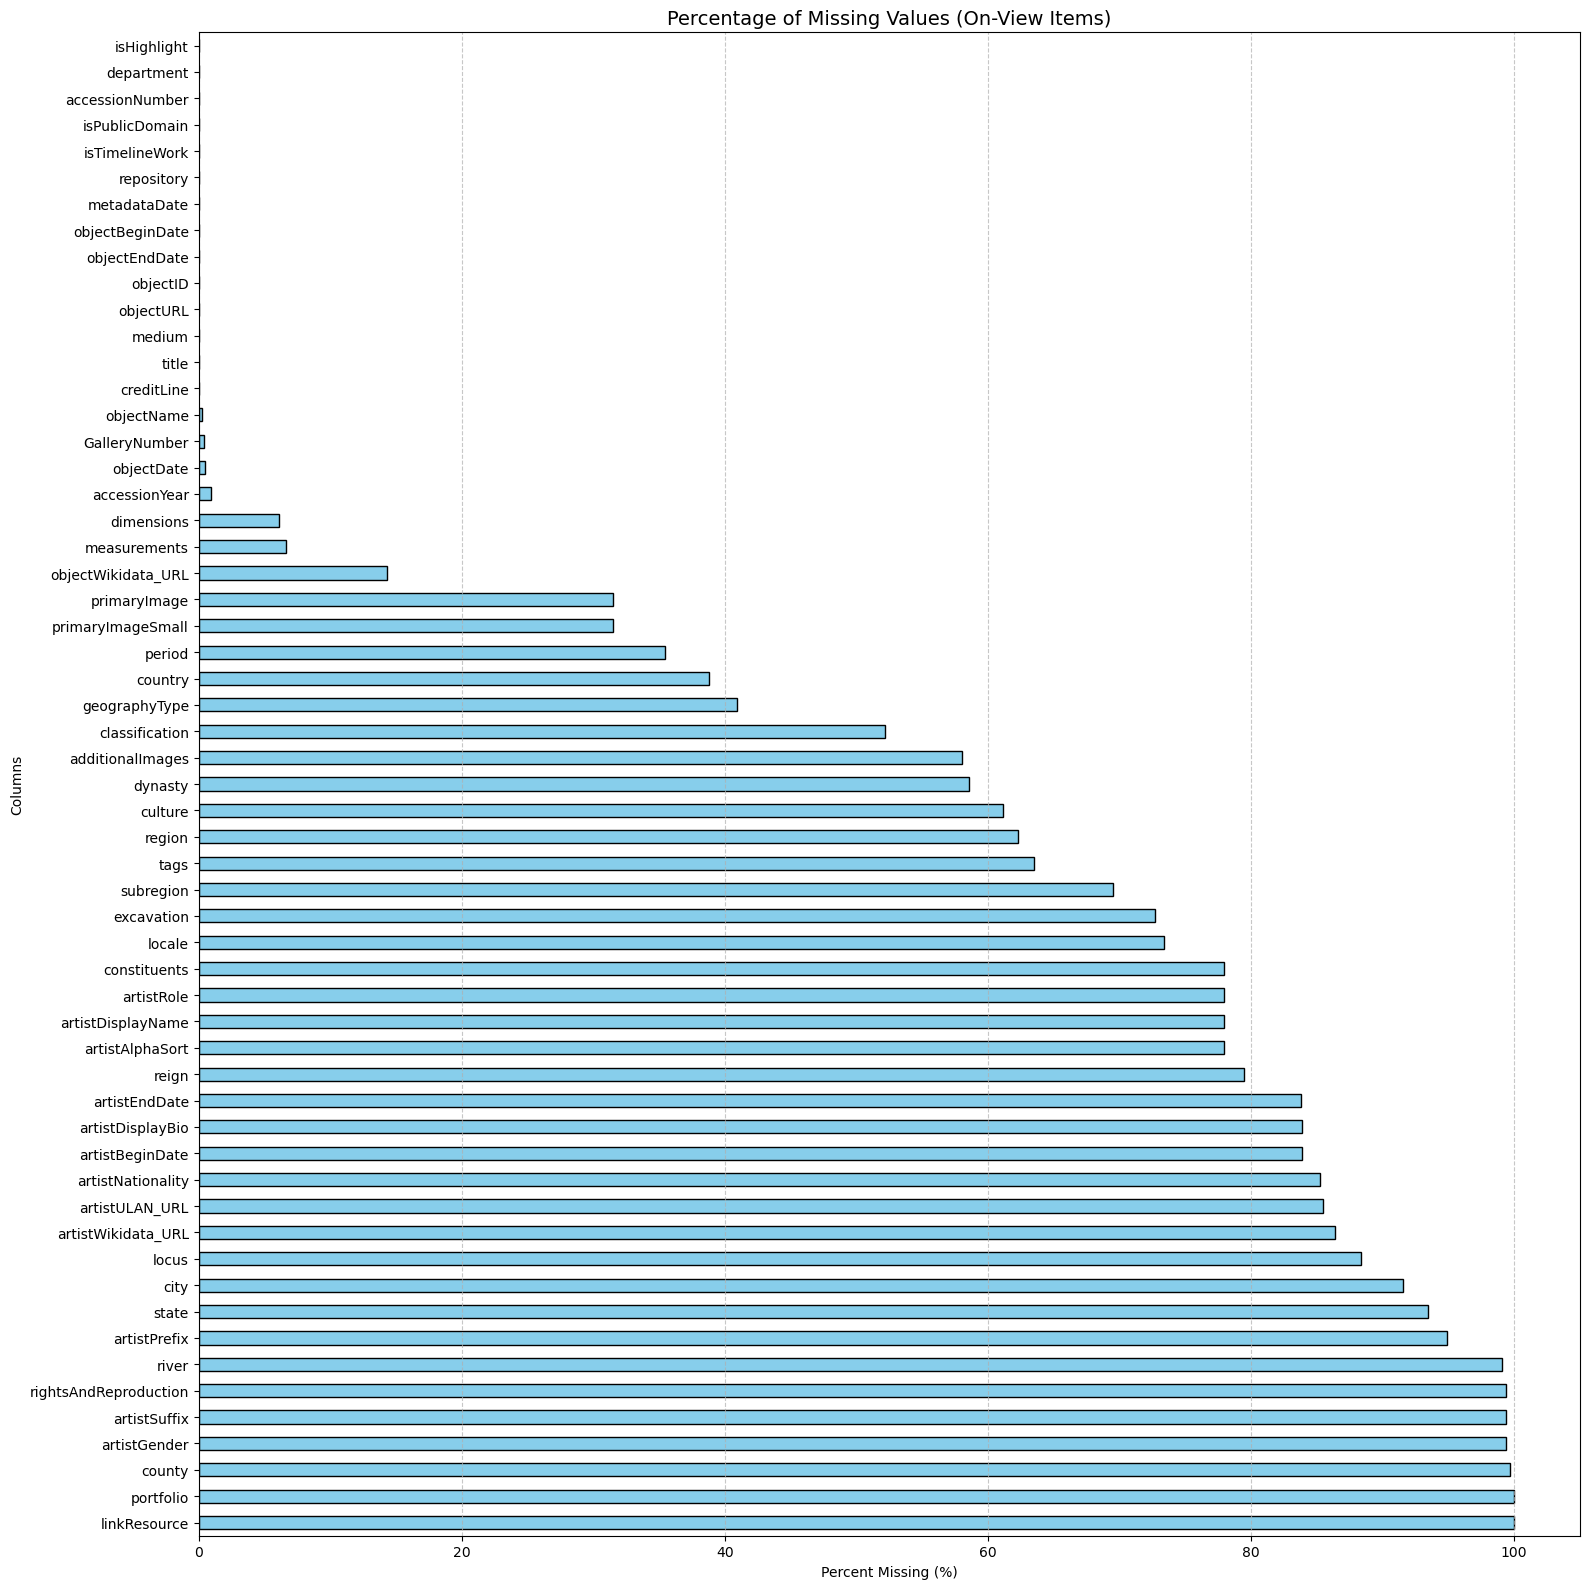

Missing values in key fields:
------------------------------
                Missing Count
tags                    28569
culture                 27492
classification          23467
period                  15949
primaryImage            14172
title                      26
medium                     24
department                  0
objectURL                   0


In [5]:
# visualize missing data for onview objects
plt.figure(figsize=(16, 16)) 
missing_pct = df_onview.isnull().mean().sort_values(ascending=False) * 100
missing_pct = missing_pct[missing_pct >= 0]

missing_pct.plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Percentage of Missing Values (On-View Items)', fontsize=14)
plt.xlabel('Percent Missing (%)')
plt.ylabel('Columns')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# check key recommendation columns
key_fields = ['title', 'department', 'culture', 'period', 'medium', 
              'classification', 'tags', 'primaryImage', 'objectURL']

print("Missing values in key fields:")
print("-" * 30)

print(df_onview[key_fields].isnull().sum().sort_values(ascending=False).to_frame(name='Missing Count'))

## 2) Inspecting column values

<Axes: >

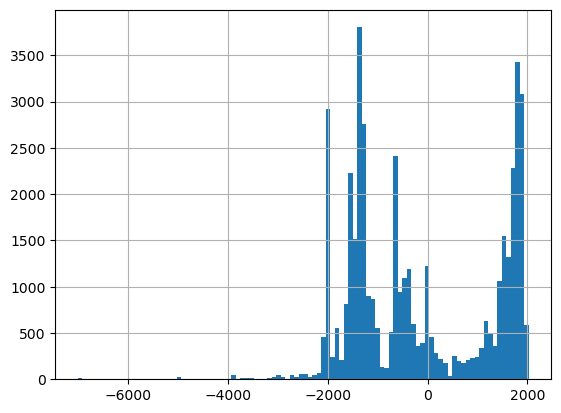

In [6]:
# distribution of when art obj was created
df_onview['objectBeginDate'].hist(bins=100)

In [7]:
# spread of art obj date spread (enddate - begindate)
df_onview['date_span'] = df_onview['objectEndDate'] - df_onview['objectBeginDate']
df_onview['date_span'].describe()

count    44973.000000
mean       100.834256
std        207.165971
min       -200.000000
25%          1.000000
50%         30.000000
75%        116.000000
max       7330.000000
Name: date_span, dtype: float64

<Axes: xlabel='century'>

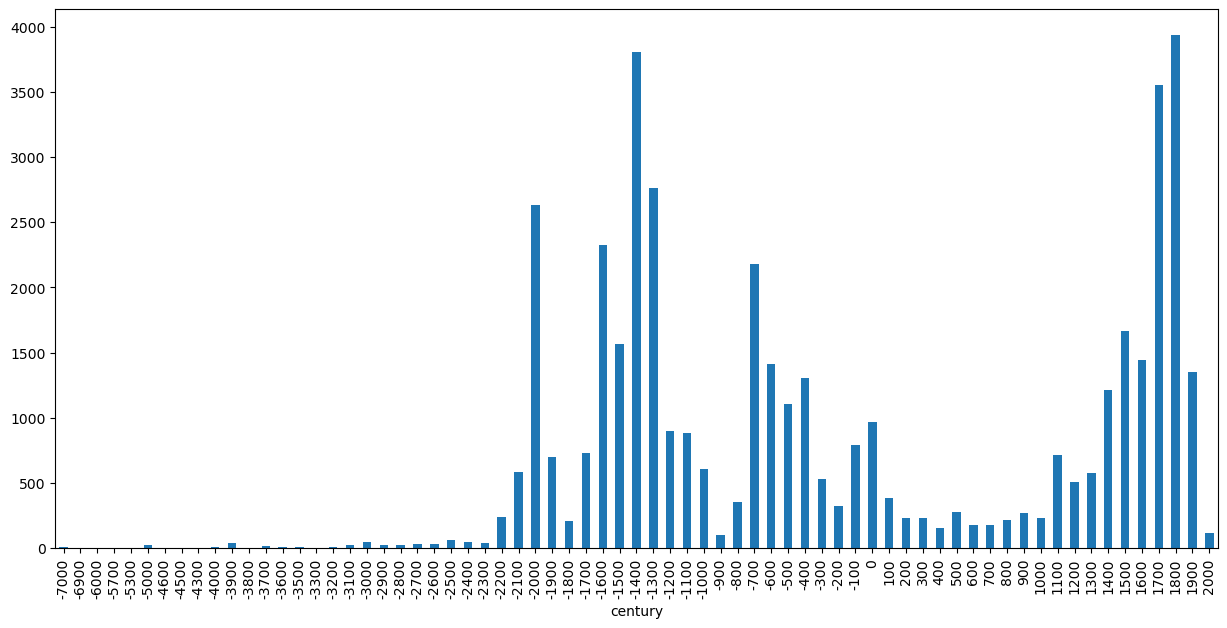

In [8]:
# works per century
df_onview['century'] = (df_onview['objectBeginDate'] // 100) * 100

fig, ax = plt.subplots(figsize=(15, 7))
df_onview['century'].value_counts().sort_index().plot(kind='bar', ax=ax)


## Inspection
i.e. where is all this stuff from?

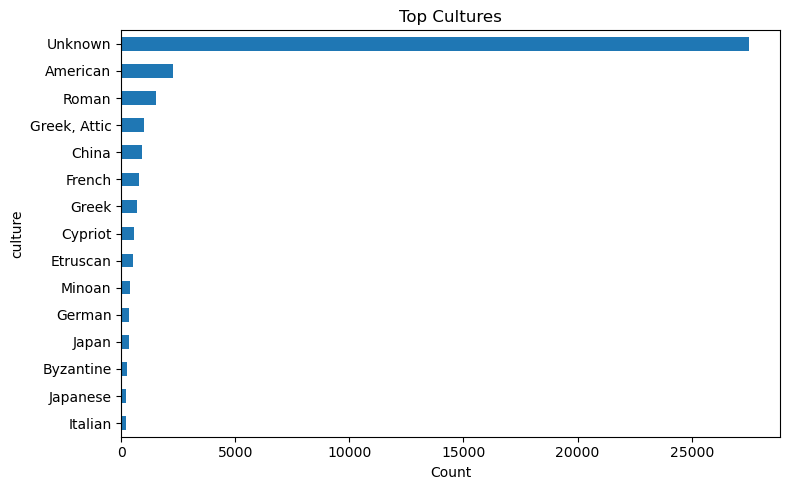

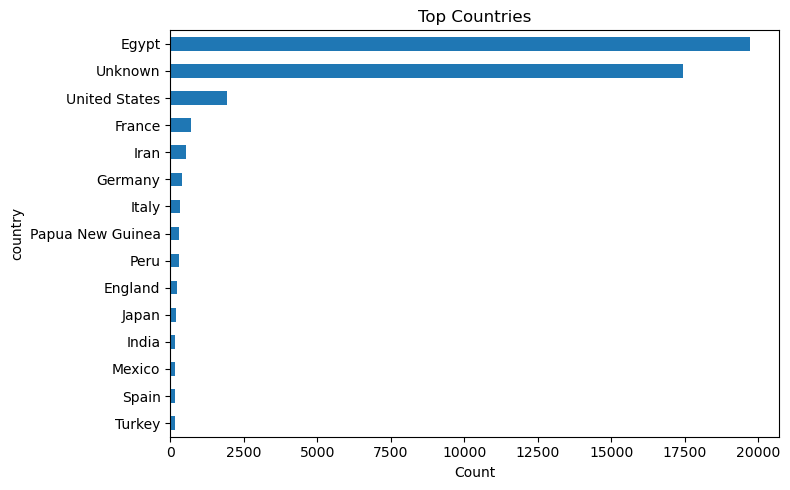

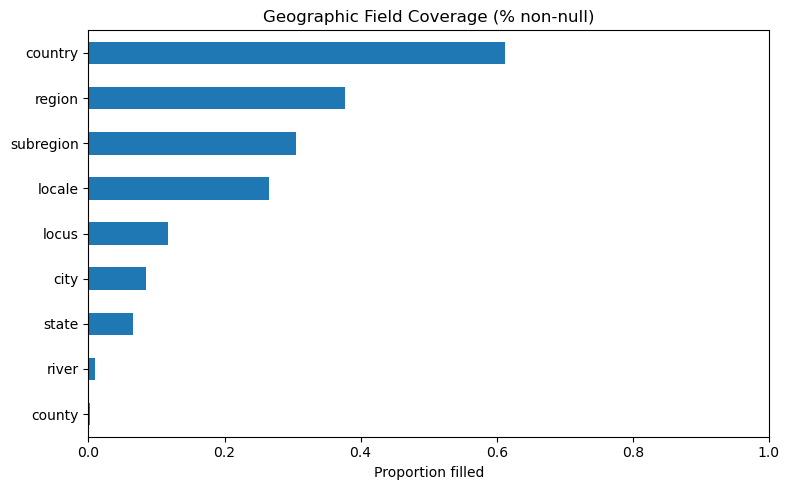

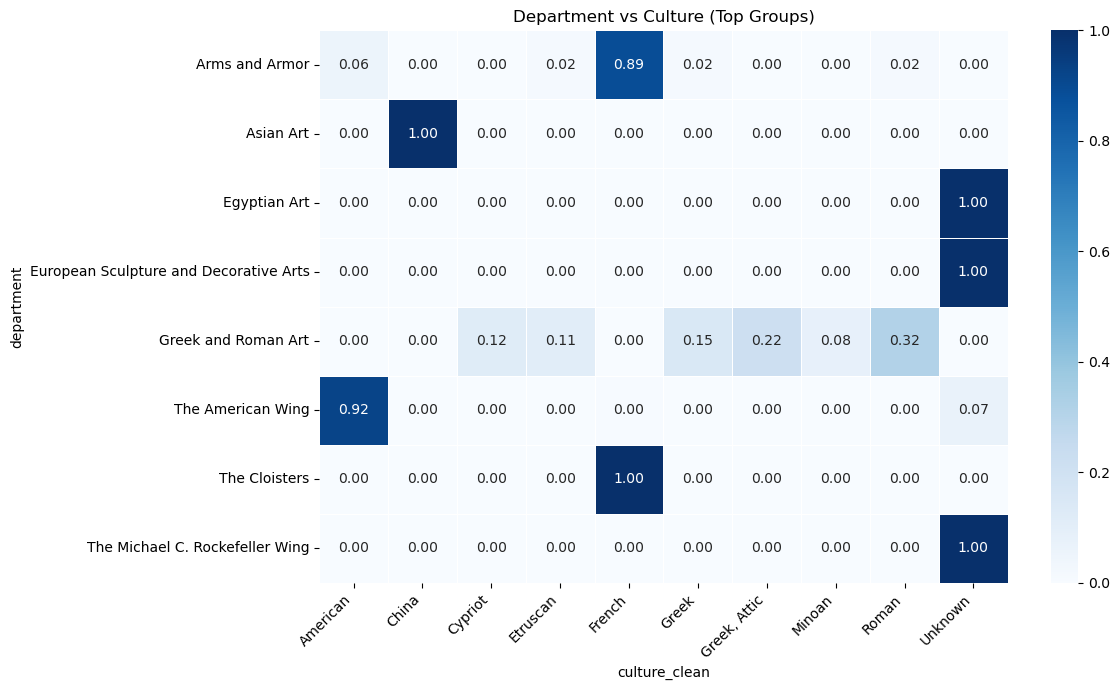

In [9]:
# top cultures
top_cultures = df_onview['culture'].fillna('Unknown').value_counts().head(15)

plt.figure(figsize=(8, 5))
top_cultures.sort_values().plot(kind='barh')
plt.title("Top Cultures")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

# top countries
top_countries = df_onview['country'].fillna('Unknown').value_counts().head(15)

plt.figure(figsize=(8, 5))
top_countries.sort_values().plot(kind='barh')
plt.title("Top Countries")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

# geogrphic field coverage (how sparse is it)
geo_fields = ['city', 'state', 'county', 'country', 'region', 
              'subregion', 'locale', 'locus', 'river']

geo_coverage = df_onview[geo_fields].notnull().mean().sort_values()

plt.figure(figsize=(8, 5))
geo_coverage.plot(kind='barh')
plt.title("Geographic Field Coverage (% non-null)")
plt.xlabel("Proportion filled")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

# make ct
df_onview['culture_clean'] = df_onview['culture'].fillna('Unknown')

top_departments = df_onview['department'].value_counts().head(8).index
top_cultures = df_onview['culture_clean'].value_counts().head(10).index

filtered = df_onview[
    df_onview['department'].isin(top_departments) &
    df_onview['culture_clean'].isin(top_cultures)
]

ct = pd.crosstab(
    filtered['department'],
    filtered['culture_clean'],
    normalize='index'
)

annot = ct.copy().round(2).astype(str)
annot[ct < 0.1] = ""   # hide weak signal

# plot
plt.figure(figsize=(12, 7))

sns.heatmap(
    ct,
    cmap='Blues',
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Department vs Culture (Top Groups)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Relationship between Met's Departments and art object's Cultural origins

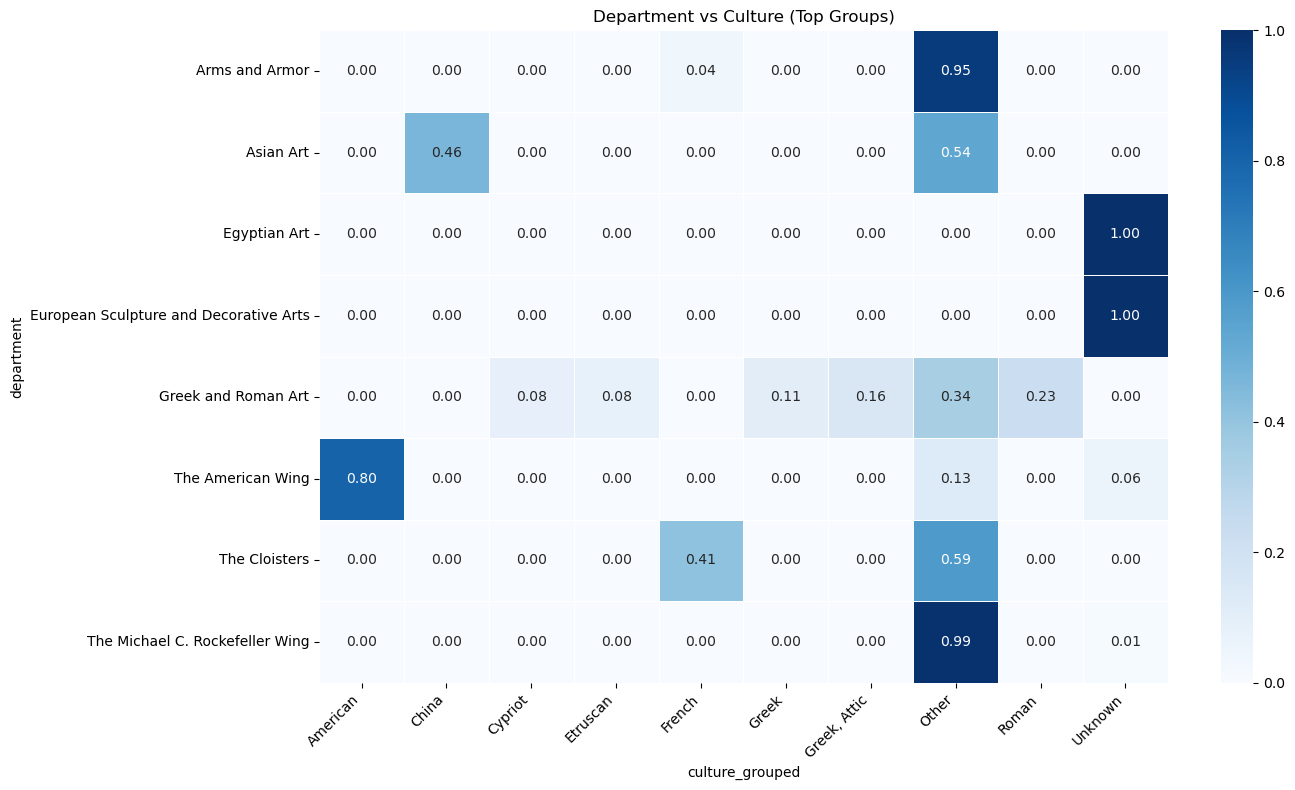

In [10]:
df_onview['culture_clean'] = (
    df_onview['culture']
    .fillna('Unknown')
    .str.strip()
)

top_cultures = df_onview['culture_clean'].value_counts().head(10).index

df_onview['culture_grouped'] = df_onview['culture_clean'].where(
    df_onview['culture_clean'].isin(top_cultures),
    'Other'
)

top_departments = df_onview['department'].value_counts().head(8).index
top_cultures = df_onview['culture_grouped'].value_counts().head(10).index

filtered = df_onview[
    df_onview['department'].isin(top_departments) &
    df_onview['culture_grouped'].isin(top_cultures)
]

ct = pd.crosstab(
    filtered['department'],
    filtered['culture_grouped'],
    normalize='index'
)

plt.figure(figsize=(14, 8))

sns.heatmap(
    ct,
    cmap='Blues',
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title('Department vs Culture (Top Groups)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

ct_filtered = ct.copy()
ct_filtered[ct_filtered < 0.1] = 0

ct_col = pd.crosstab(
    filtered['department'],
    filtered['culture_grouped'],
    normalize='columns'
)

## Department and classification

classification
Vases                          2176
Paintings                      1407
Glass                          1150
Bronzes                         961
Ceramics                        914
Sculpture                       862
Ceramics-Porcelain              736
Terracottas                     663
Stone Sculpture                 572
Ceramics-Pottery                562
Gold and Silver                 551
Gems                            540
Sculpture-Architectural         515
Metalwork-Silver                409
Woodwork-Furniture              404
Wood-Sculpture                  369
Glass-Stained                   276
Metalwork                       270
Sculpture-Bronze                249
Metal-Ornaments                 216
Photographs                     207
Bark-Paintings                  192
Swords                          172
Medals and Plaquettes           169
Jade                            158
Codices                         157
Helmets                         142
Metalwork-Gol

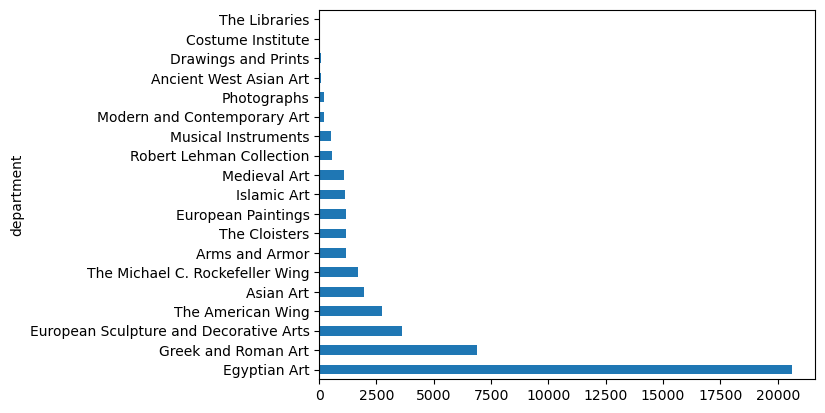

In [11]:
# work per department
df_onview['department'].value_counts().plot(kind='barh')

# classification distribution
df_onview['classification'].value_counts().head(30)

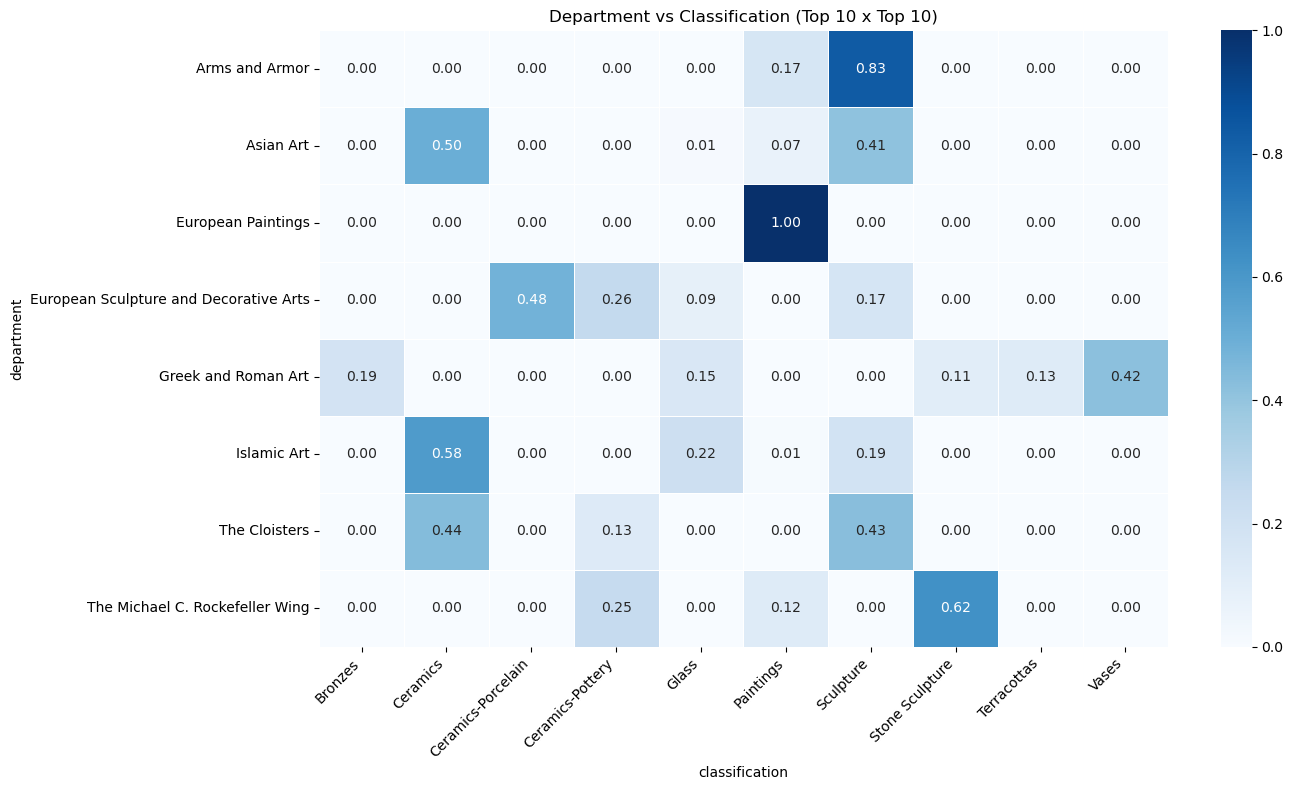

In [12]:
top_departments = df_onview['department'].value_counts().head(10).index
top_classifications = df_onview['classification'].value_counts().head(10).index

filtered = df_onview[
    df_onview['department'].isin(top_departments) &
    df_onview['classification'].isin(top_classifications)
]

ct = pd.crosstab(
    filtered['department'],
    filtered['classification'],
    normalize='index'
)

plt.figure(figsize=(14, 8))

sns.heatmap(
    ct,
    cmap='Blues',
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title('Department vs Classification (Top 10 x Top 10)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

ct = ct[ct.sum().sort_values(ascending=False).index]

ct_filtered = ct.copy()
ct_filtered[ct_filtered < 0.1] = 0  # hide weak relationships bc we have so many

## looking at the tags -- these are keywords associated with the art obj (specifically for Met's existing search engine)

In [13]:
import ast

# Parse tags (stored as stringified list of dicts)
def extract_tag_terms(tag_str):
    if pd.isnull(tag_str):
        return []
    try:
        return [t['term'] for t in ast.literal_eval(tag_str)]
    except:
        return []

df_onview['tag_list'] = df_onview['tags'].apply(extract_tag_terms)
df_onview['tag_count'] = df_onview['tag_list'].apply(len)

# Most common tags
from collections import Counter
all_tags = [t for tags in df_onview['tag_list'] for t in tags]
Counter(all_tags).most_common(30)

# Distribution of tag count per object
df_onview['tag_count'].value_counts().sort_index()

# How many objects have NO tags? (affects recommendation quality)
(df_onview['tag_count'] == 0).sum()

29074

Summary: 
- So looks like 65% (29074/50k) have no tags

In [14]:
# which departments are the untagged objects concentrated in?
untagged = df_onview[df_onview['tag_count'] == 0]
untagged['department'].value_counts()

department
Egyptian Art                              16857
Greek and Roman Art                        3535
The American Wing                          1741
European Sculpture and Decorative Arts     1260
The Michael C. Rockefeller Wing             990
Arms and Armor                              952
Asian Art                                   924
The Cloisters                               630
Islamic Art                                 588
Medieval Art                                491
Musical Instruments                         460
Robert Lehman Collection                    203
Modern and Contemporary Art                 161
Photographs                                 122
European Paintings                           58
Ancient West Asian Art                       50
Drawings and Prints                          22
Costume Institute                            19
The Libraries                                11
Name: count, dtype: int64

In [15]:
# distribution of tagged obj
tagged = df_onview[df_onview['tag_count'] > 0]
print(f"Tagged: {len(tagged)} ({len(tagged)/len(df_onview)*100:.1f}%)")
tagged['tag_count'].describe()

Tagged: 15899 (35.4%)


count    15899.000000
mean         1.907416
std          1.224712
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max         14.000000
Name: tag_count, dtype: float64

## image avaliability

### are public domain images associated with having an image?

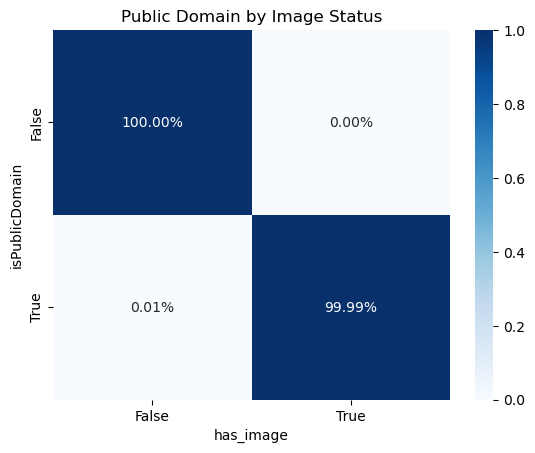

In [16]:
# are public domain images associated with having an image?
df_onview['has_image'] = df_onview['primaryImage'].notnull()

# img availability by department
df_onview.groupby('department')['has_image'].mean().sort_values()

# img availability by era
df_onview.groupby('century')['has_image'].mean().sort_values()

ct = pd.crosstab(df_onview['isPublicDomain'], df_onview['has_image'], normalize='index')

sns.heatmap(ct, annot=True, cmap='Blues', fmt='.2%')
plt.title('Public Domain by Image Status')
plt.show()


### Is there a correlation between an artwork having tags and the artwork having an avaliable image?

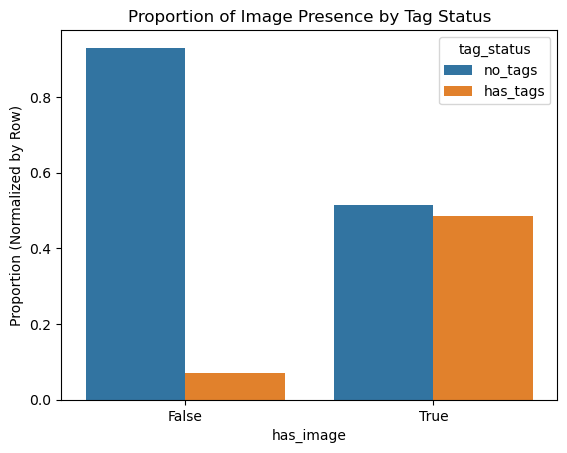

In [17]:
# Is there a correlation between an artwork having tags and the artwork having an avaliable image?
ct = pd.crosstab(
    df_onview['has_image'], 
    df_onview['tag_count'] > 0, 
    normalize='index'
).rename(columns={False: 'no_tags', True: 'has_tags'})

# reset index
ct_plot = ct.reset_index().melt(id_vars='has_image', var_name='tag_status', value_name='proportion')

sns.barplot(data=ct_plot, x='has_image', y='proportion', hue='tag_status')
plt.title('Proportion of Image Presence by Tag Status')
plt.ylabel('Proportion (Normalized by Row)')
plt.show()

## image

537 objects with ≤2 populated rec fields
department
Modern and Contemporary Art               150
The American Wing                         135
Photographs                               117
European Sculpture and Decorative Arts     99
The Libraries                              10
Egyptian Art                                8
Drawings and Prints                         3
Musical Instruments                         3
The Michael C. Rockefeller Wing             3
Costume Institute                           3
European Paintings                          2
Ancient West Asian Art                      1
Robert Lehman Collection                    1
Greek and Roman Art                         1
Islamic Art                                 1
Name: count, dtype: int64


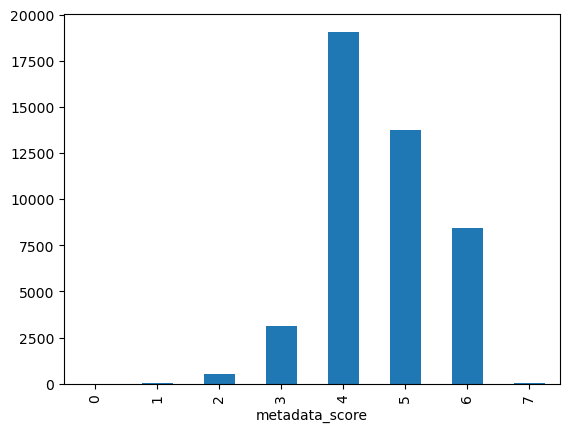

In [18]:
# score art obj by how many key fields are populated
rec_fields = ['culture', 'period', 'medium', 'classification', 
              'country', 'dynasty', 'tags', 'primaryImage']

df_onview['metadata_score'] = df_onview[rec_fields].notnull().sum(axis=1)

df_onview['metadata_score'].value_counts().sort_index().plot(kind='bar')

# things with less info (hard to recommend)
low_signal = df_onview[df_onview['metadata_score'] <= 2]
print(f"{len(low_signal)} objects with ≤2 populated rec fields")
print(low_signal['department'].value_counts())

## Looking at artistWikiData

### Is having objectWikidata_URL associated with having an image OR being public domain?

In [19]:
# bool masks -- I'm checking if objectWikidata_URL is associated with having an image or being public domain
has_wikidata = df_onview['objectWikidata_URL'].notnull()
is_public    = df_onview['isPublicDomain']
has_image    = df_onview['primaryImage'].notnull()

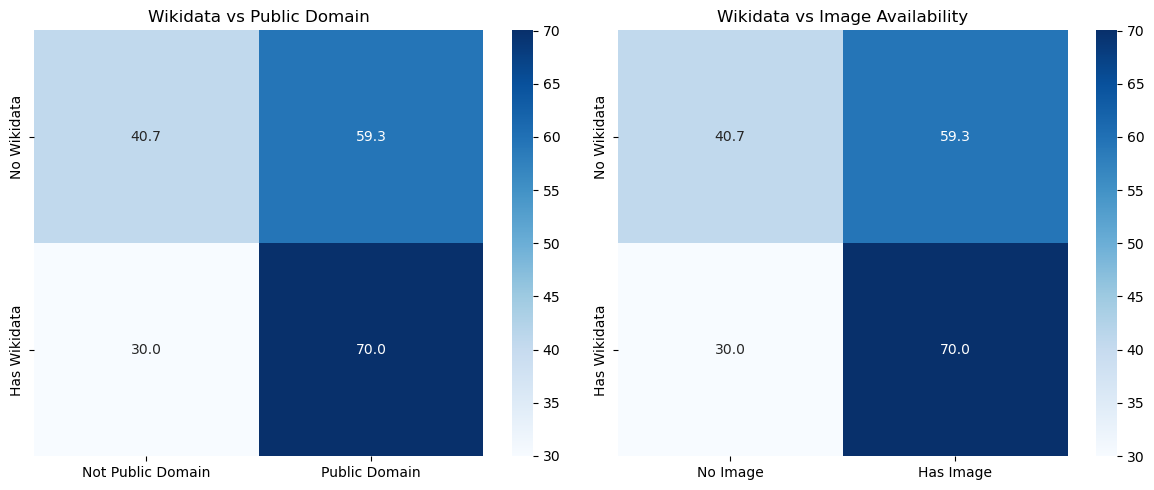

In [20]:
# Crosstabs
ct_public = pd.crosstab(has_wikidata, is_public, normalize='index') * 100
ct_image  = pd.crosstab(has_wikidata, has_image, normalize='index') * 100

# Make labels nicer
ct_public.index = ['No Wikidata', 'Has Wikidata']
ct_public.columns = ['Not Public Domain', 'Public Domain']

ct_image.index = ['No Wikidata', 'Has Wikidata']
ct_image.columns = ['No Image', 'Has Image']

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(ct_public, annot=True, fmt=".1f", cmap="Blues", ax=axes[0])
axes[0].set_title("Wikidata vs Public Domain")

sns.heatmap(ct_image, annot=True, fmt=".1f", cmap="Blues", ax=axes[1])
axes[1].set_title("Wikidata vs Image Availability")

plt.tight_layout()
plt.show()

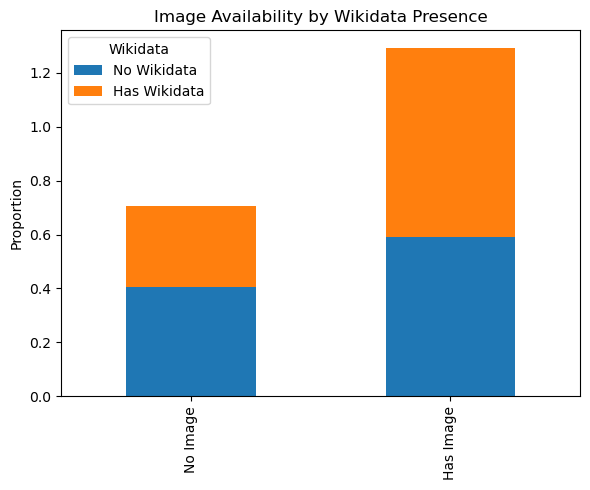

In [21]:
ct_image_plot = ct_image.div(100)  # convert back to proportions

ct_image_plot.T.plot(
    kind='bar',
    stacked=True,
    figsize=(6, 5)
)

plt.title("Image Availability by Wikidata Presence")
plt.ylabel("Proportion")
plt.legend(title="Wikidata")
plt.tight_layout()
plt.show()

In [22]:
# check to see if the correlation between having an artwork wikipedia article against Has Image and isPublicDomain
from scipy.stats import chi2_contingency

for label, col in [('Public Domain', is_public), ('Has Image', has_image)]:
    ct = pd.crosstab(has_wikidata, col)
    chi2, p, dof, _ = chi2_contingency(ct)
    print(f"Wikidata vs {label}: chi2={chi2:.1f}, p={p:.4f}")

Wikidata vs Public Domain: chi2=294.1, p=0.0000
Wikidata vs Has Image: chi2=294.5, p=0.0000


## Gallery Number

In [23]:
df_onview['GalleryNumber'].value_counts()

GalleryNumber
122    4541
171    3462
109    2938
130    2901
120    2090
       ... 
902       1
165       1
203       1
005       1
023       1
Name: count, Length: 414, dtype: int64

<Axes: xlabel='GalleryNumber'>

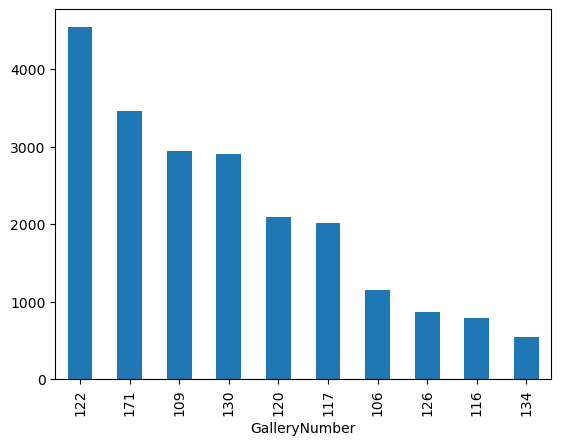

In [24]:
df_onview['GalleryNumber'].value_counts().head(10).plot(kind='bar')

## Other Questions:
1. is 'dynasty' associated with Asian countries in particular?
2. what countries, cultures is 'period' associated with (I'm guessing the nulls are from Unknown)
3. from the 269 artists that have a tagged gender, what is the distribution and where are they from?
4. word cloud with 'Title' names
5. What are the most common materials/techniques, and how do they cluster by department or culture? (will affect our recommendation)
6. Artist nationality vs culture field — do they agree? There are ~10k objects with artist info — is artistNationality redundant with culture or does it add signal?)
7. Co-occurrence of null fields — do objects tend to be missing multiple key fields together? (identifies structurally sparse objects that will be hard to recommend)
8. isHighlight objects — are the 269 highlighted works a good representation of the full collection, or skewed toward certain departments/eras? (useful as a quality benchmark set)

In [25]:
from collections import Counter

# Which departments / cultures have dynasty populated?
dynasty_dept = (
    df_onview[df_onview['dynasty'].notnull()]
    ['department'].value_counts()
)

dynasty_culture = (
    df_onview[df_onview['dynasty'].notnull()]
    ['culture'].value_counts()
)

print("=== Dynasty: top departments ===")
print(dynasty_dept)
print("\n=== Dynasty: top cultures ===")
print(dynasty_culture)


=== Dynasty: top departments ===
department
Egyptian Art    18647
Name: count, dtype: int64

=== Dynasty: top cultures ===
Series([], Name: count, dtype: int64)


Interesting... it looks like the Egyptian department is EXTREMELY well documented, and for this current pass of OnView Met objects, there aren't a lot of Other dynasties on display apart from Egyptian art...

### Period

In [26]:
period_country = (
    df_onview[df_onview['period'].notnull() & df_onview['country'].notnull()]
    ['country'].value_counts().head(20)
)

period_culture = (
    df_onview[df_onview['period'].notnull() & df_onview['culture'].notnull()]
    ['culture'].value_counts().head(20)
)

# Null breakdown
period_null_by_dept = df_onview.groupby('department')['period'].apply(
    lambda x: x.isnull().mean() * 100
).sort_values()

print("\n=== Period: top countries (non-null) ===")
print(period_country)
print("\n=== Period: top cultures (non-null) ===")
print(period_culture)
print("\n=== Period: % null by department ===")
print(period_null_by_dept.round(1))


=== Period: top countries (non-null) ===
country
Egypt                     19586
Nubia (Sudan)                37
China                        12
Egypt and Sudan              12
Colombia                      9
Peru                          8
Mexico                        6
Canaan                        6
Indonesia                     4
Cyprus                        4
Egypt or Italy                4
Greece                        2
Italy                         2
Egypt or Nubia (Sudan)        1
Turkey                        1
Japan                         1
Colombia?                     1
China or Korea                1
Gaul                          1
Africa                        1
Name: count, dtype: int64

=== Period: top cultures (non-null) ===
culture
Roman                              1389
Greek, Attic                       1014
China                               881
Greek                               687
Cypriot                             526
Etruscan                           

### Artist gender

In [27]:
gendered = df_onview[df_onview['artistGender'].notnull()].copy()

print(f"\n=== Gender-tagged artists: {len(gendered)} objects ===")
print(gendered['artistGender'].value_counts())
print("\n--- Nationality breakdown ---")
print(gendered['artistNationality'].value_counts().head(15))
print("\n--- Department breakdown ---")
print(gendered['department'].value_counts())

# Time distribution — when were these artists active?
print("\n--- Century breakdown ---")
gendered['century'] = (gendered['objectBeginDate'] // 100) * 100
print(gendered['century'].value_counts().sort_index())


=== Gender-tagged artists: 269 objects ===
artistGender
Female    269
Name: count, dtype: int64

--- Nationality breakdown ---
artistNationality
American                                 141
French                                    28
Swiss                                      6
British                                    5
Italian                                    5
Native American, San Ildefonso Pueblo      2
Chinese                                    2
Australian                                 2
Dutch                                      2
American, born Austria                     2
Japanese                                   1
American, born India                       1
American, born Denmark                     1
Malian                                     1
Native American                            1
Name: count, dtype: int64

--- Department breakdown ---
department
The American Wing                         81
Egyptian Art                              60
Photographs           

### MEDIUM — top materials + by department

In [28]:
medium_counts = df_onview['medium'].value_counts().head(25)
print("\n=== Top 25 mediums ===")
print(medium_counts)

# Extract first material token (broad category)
df_onview['medium_broad'] = df_onview['medium'].str.split(
    r'[;,\s]', n=1
).str[0].str.strip().str.lower()

print("\n--- Broad medium tokens (top 20) ---")
print(df_onview['medium_broad'].value_counts().head(20))


=== Top 25 mediums ===
medium
Faience                            4495
Terracotta                         2934
Bronze                             1701
Glass                              1630
Limestone, paint                   1219
Pottery and ink, paint             1011
Oil on canvas                      1000
Gold                                960
Pottery                             811
Limestone                           792
Marble                              767
Travertine (Egyptian alabaster)     686
Silver                              631
Wood                                622
Glazed steatite                     492
Steatite                            478
Stone                               430
Mud                                 376
Blue faience                        347
Steatite (glazed)                   339
Bronze or copper alloy              332
Carnelian                           319
Hard-paste porcelain                291
Earthenware                         274
Linen    

### Null Co-occurence


=== Metadata score distribution (0=fully sparse, 10=fully populated) ===
metadata_score
1        4
2       28
3      103
4     1925
5    15799
6    17040
7     8776
8     1298
Name: count, dtype: int64

Sparse objects (score ≤ 3): 135 (0.3%)
department
The American Wing                         81
Modern and Contemporary Art               16
European Sculpture and Decorative Arts    10
Egyptian Art                              10
The Libraries                             10
Musical Instruments                        2
European Paintings                         1
Photographs                                1
Ancient West Asian Art                     1
Greek and Roman Art                        1
Costume Institute                          1
Islamic Art                                1
Name: count, dtype: int64

=== Null correlation matrix ===
                   culture  period  medium  classification  country  dynasty  \
culture               1.00   -0.27    0.01            0.59    -0.38

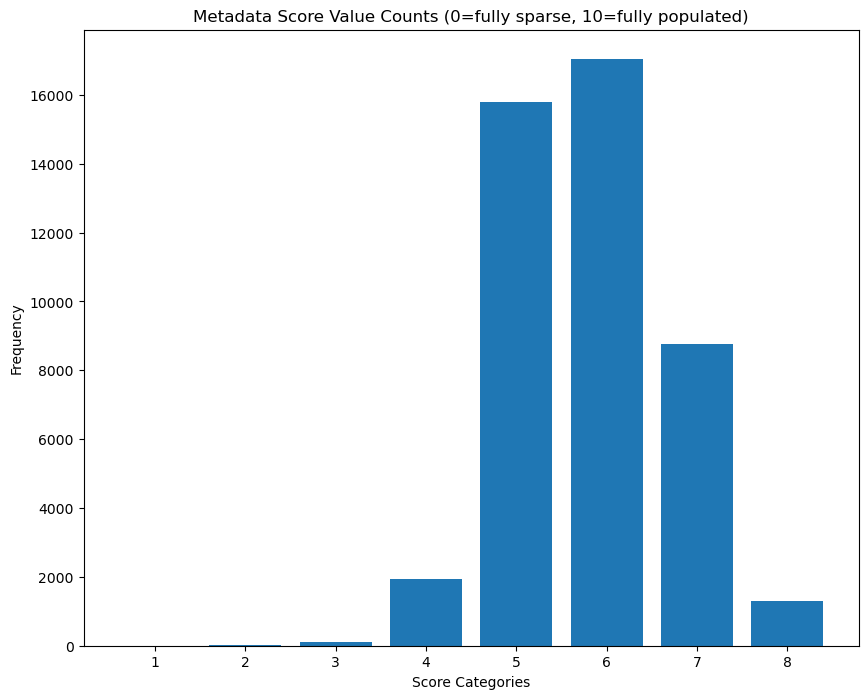

In [29]:
rec_fields = ['culture', 'period', 'medium', 'classification',
              'country', 'dynasty', 'tags', 'primaryImage',
              'objectName', 'artistDisplayName']

df_onview['null_count'] = df_onview[rec_fields].isnull().sum(axis=1)
df_onview['metadata_score'] = len(rec_fields) - df_onview['null_count']

print("\n=== Metadata score distribution (0=fully sparse, 10=fully populated) ===")
print(df_onview['metadata_score'].value_counts().sort_index())

metadata_score_valcount = df_onview['metadata_score'].value_counts().sort_index()

# Objects with ≤3 populated fields — hard to recommend
sparse = df_onview[df_onview['metadata_score'] <= 3]
print(f"\nSparse objects (score ≤ 3): {len(sparse)} ({len(sparse)/len(df_onview)*100:.1f}%)")
print(sparse['department'].value_counts())

# Null co-occurrence heatmap (correlation between fields being null)
null_corr = df_onview[rec_fields].isnull().astype(int).corr()
print("\n=== Null correlation matrix ===")
print(null_corr.round(2))

plt.figure(figsize=(10,8))
plt.bar(metadata_score_valcount.index, metadata_score_valcount.values)
plt.xlabel('Score Categories')
plt.ylabel('Frequency')
plt.title('Metadata Score Value Counts (0=fully sparse, 10=fully populated)')
plt.show()

### isHighlight a good representation of artworks?

Highlighted objects: 1060 / 44973 total (2.4%)

=== Department representation ===
                                        full_collection_%  highlights_%  \
department                                                                
The Libraries                                         0.0           0.9   
Musical Instruments                                   1.2           6.9   
European Paintings                                    2.6          11.3   
Robert Lehman Collection                              1.3           5.0   
Ancient West Asian Art                                0.2           0.8   
Islamic Art                                           2.5           6.3   
Asian Art                                             4.3           9.9   
The Michael C. Rockefeller Wing                       3.7           8.2   
Drawings and Prints                                   0.2           0.4   
The Cloisters                                         2.6           4.7   
Arms and Armor    

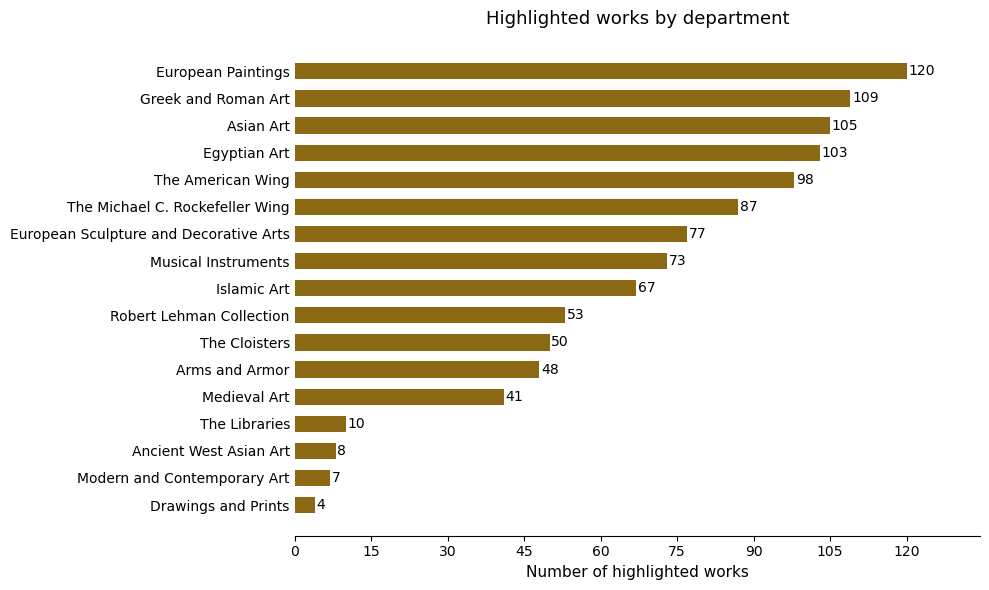

In [30]:
# ============================================================
# isHighlight — representativeness analysis
# ============================================================

highlight = df_onview[df_onview['isHighlight'] == True].copy()
full      = df_onview.copy()

print(f"Highlighted objects: {len(highlight)} / {len(full)} total ({len(highlight)/len(full)*100:.1f}%)")

# ============================================================
# 1. DEPARTMENT — highlight rate per department
# ============================================================
dept_comparison = pd.DataFrame({
    'full_collection_%': full['department'].value_counts(normalize=True) * 100,
    'highlights_%':      highlight['department'].value_counts(normalize=True) * 100,
}).fillna(0).round(1)

dept_comparison['highlight_rate_%'] = (
    highlight['department'].value_counts() /
    full['department'].value_counts() * 100
).fillna(0).round(1)

dept_comparison = dept_comparison.sort_values('highlight_rate_%', ascending=False)
print("\n=== Department representation ===")
print(dept_comparison)

print('-'*30, '\n')


# ============================================================
# 2. ERA — century-level comparison
# ============================================================
full['century']      = (full['objectBeginDate'] // 100) * 100
highlight['century'] = (highlight['objectBeginDate'] // 100) * 100

era_comparison = pd.DataFrame({
    'full_collection_%': full['century'].value_counts(normalize=True) * 100,
    'highlights_%':      highlight['century'].value_counts(normalize=True) * 100,
}).fillna(0).round(1)

era_comparison['overrepresentation'] = (
    era_comparison['highlights_%'] - era_comparison['full_collection_%']
).round(1)

era_comparison = era_comparison.sort_values('overrepresentation', ascending=False)
print("\n=== Era representation (sorted by over/under-representation) ===")
print(era_comparison)

print('-'*30, '\n')

# ============================================================
# 3. METADATA QUALITY — are highlights better documented?
# ============================================================
rec_fields = ['culture', 'period', 'medium', 'classification',
              'country', 'dynasty', 'tags', 'primaryImage',
              'objectName', 'artistDisplayName']

print("\n=== Metadata completeness: highlights vs full collection ===")
for field in rec_fields:
    full_pct      = full[field].notnull().mean() * 100
    highlight_pct = highlight[field].notnull().mean() * 100
    diff = highlight_pct - full_pct
    marker = ' ▲' if diff > 10 else (' ▼' if diff < -10 else '')
    print(f"  {field:<22} full: {full_pct:5.1f}%   highlights: {highlight_pct:5.1f}%   diff: {diff:+.1f}%{marker}")

print('-'*30, '\n')

# ============================================================
# 4. IMAGE AVAILABILITY
# ============================================================
full_img_rate      = full['primaryImage'].notnull().mean() * 100
highlight_img_rate = highlight['primaryImage'].notnull().mean() * 100

print(f"\n=== Image availability ===")
print(f"  Full collection:  {full_img_rate:.1f}%")
print(f"  Highlights:       {highlight_img_rate:.1f}%")

print('-'*30, '\n')

# ============================================================
# 5. PUBLIC DOMAIN
# ============================================================
print("\n=== Public domain rate ===")
print(pd.DataFrame({
    'full_collection': full['isPublicDomain'].value_counts(normalize=True).mul(100).round(1),
    'highlights':      highlight['isPublicDomain'].value_counts(normalize=True).mul(100).round(1),
}))

print('-'*30, '\n')

# ============================================================
# 6. TOP HIGHLIGHTS — bar chart by department
# ============================================================

highlight_dept = (
    highlight['department']
    .value_counts()
    .sort_values(ascending=True)  # ascending so longest bar is at top
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    highlight_dept.index,
    highlight_dept.values,
    color='#8B6914',
    edgecolor='none',
    height=0.6
)

# Add count labels at end of each bar
for bar, val in zip(bars, highlight_dept.values):
    ax.text(
        bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
        str(val), va='center', ha='left', fontsize=10
    )

import matplotlib.ticker as mtick 
ax.set_xlabel('Number of highlighted works', fontsize=11)
ax.set_title('Highlighted works by department', fontsize=13, fontweight='normal', pad=12)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='y', length=0)
ax.set_xlim(0, highlight_dept.values.max() * 1.12)  # headroom for labels
ax.xaxis.set_major_locator(mtick.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

---
### Scratch: Just looking at the tag structure, artwork links

In [31]:
# scratch
# looking up tags and Wikipedia Data
subset = df_onview.loc[:, ['objectID', 'objectWikidata_URL', 'objectURL', 'tags']]
subset.head()

,objectID,objectWikidata_URL,objectURL,tags
0,460813,https://www.wikidata.org/wiki/Q20188136,https://www.metmuseum.org/art/collection/searc...,"[{""term"": ""Infants"", ""AAT_URL"": ""http://vocab...."
1,461279,https://www.wikidata.org/wiki/Q20188270,https://www.metmuseum.org/art/collection/searc...,"[{""term"": ""Women"", ""AAT_URL"": ""http://vocab.ge..."
2,24991,https://www.wikidata.org/wiki/Q78813071,https://www.metmuseum.org/art/collection/searc...,NaN
3,461472,https://www.wikidata.org/wiki/Q20188280,https://www.metmuseum.org/art/collection/searc...,"[{""term"": ""Christ"", ""AAT_URL"": ""http://vocab.g..."
4,503615,https://www.wikidata.org/wiki/Q29385647,https://www.metmuseum.org/art/collection/searc...,NaN


In [32]:
# compare nan values for wikipedia link vs Met link
print("wiki link nan: ", subset['objectWikidata_URL'].isnull().sum())
print("met link nan: ", subset['objectURL'].isnull().sum())
print()
print("tags nan: ", subset['tags'].isnull().sum())


wiki link nan:  6434
met link nan:  0

tags nan:  28569


In [33]:
# let's see if the links are legit...

# make pandas show full values 
with pd.option_context('display.max_colwidth', None):
    print(subset[['objectID','objectURL']].head(10))

# reset the full values option
pd.reset_option('display.max_colwidth')
pd.reset_option('display.max_rows')

   objectID                                               objectURL
0    460813  https://www.metmuseum.org/art/collection/search/460813
1    461279  https://www.metmuseum.org/art/collection/search/461279
2     24991   https://www.metmuseum.org/art/collection/search/24991
3    461472  https://www.metmuseum.org/art/collection/search/461472
4    503615  https://www.metmuseum.org/art/collection/search/503615
5    461346  https://www.metmuseum.org/art/collection/search/461346
6    461715  https://www.metmuseum.org/art/collection/search/461715
7    459006  https://www.metmuseum.org/art/collection/search/459006
8    461001  https://www.metmuseum.org/art/collection/search/461001
9    461717  https://www.metmuseum.org/art/collection/search/461717


In [34]:
# look at tags
with pd.option_context('display.max_colwidth', None):
    print(subset[['objectID','tags']].head(5))

# reset the full values option
pd.reset_option('display.max_colwidth')
pd.reset_option('display.max_rows')

   objectID  \
0    460813   
1    461279   
2     24991   
3    461472   
4    503615   

                                                                                                                                                                                                                                                                                                                                                                                                               tags  
0             [{"term": "Infants", "AAT_URL": "http://vocab.getty.edu/page/aat/300189561", "Wikidata_URL": "https://www.wikidata.org/wiki/Q998"}, {"term": "Women", "AAT_URL": "http://vocab.getty.edu/page/aat/300025943", "Wikidata_URL": "https://www.wikidata.org/wiki/Q467"}, {"term": "Moses", "AAT_URL": "http://vocab.getty.edu/page/ia/901000167", "Wikidata_URL": "https://www.wikidata.org/wiki/Q9077"}]  
1  [{"term": "Women", "AAT_URL": "http://vocab.getty.edu/page/aat/300025943", "Wikidata_URL": "ht

---
Notes: 
- we may need to parse the tags to remove the links

Sample Structure:
```
[{"term": "Infants", "AAT_URL": "http://vocab.getty.edu/page/aat/300189561", "Wikidata_URL": "https://www.wikidata.org/wiki/Q998"}, {"term": "Women", "AAT_URL": "http://vocab.getty.edu/page/aat/300025943", "Wikidata_URL": "https://www.wikidata.org/wiki/Q467"}, {"term": "Moses", "AAT_URL": "http://vocab.getty.edu/page/ia/901000167", "Wikidata_URL": "https://www.wikidata.org/wiki/Q9077"}] 
```

---

In [35]:
# function to parse the tags

import ast

# 1) vectorized tag extraction
def extract_terms_fast(cell):
    # fast NaN check (faster than pd.isna in tight loops)
    if cell is None or cell != cell:  # NaN trick: NaN != NaN
        return None

    # already parsed case
    if isinstance(cell, list):
        data = cell
    else:
        # only parse if it's a string
        if not isinstance(cell, str):
            return []
        try:
            data = ast.literal_eval(cell)
        except Exception:
            return []

    # extract terms
    return [d.get("term") for d in data if isinstance(d, dict) and "term" in d]


# 2) test it out + explicit concat

df_onview["parsedTags"] = df_onview["tags"].apply(extract_terms_fast)

df_onview.head()

,GalleryNumber,accessionNumber,accessionYear,additionalImages,artistAlphaSort,artistBeginDate,artistDisplayBio,artistDisplayName,artistEndDate,artistGender,...,century,culture_clean,culture_grouped,tag_list,tag_count,has_image,metadata_score,medium_broad,null_count,parsedTags
0,951,1975.1.1580,1975.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1700,probably French (Nevers),Other,"[Infants, Women, Moses]",3,True,6,figures,4,"[Infants, Women, Moses]"
1,951,1975.1.1555,1975.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1700,probably Bohemia or Lower Austria,Other,"[Women, Crucifixion, Saints]",3,True,6,colorless,4,"[Women, Crucifixion, Saints]"
2,379,"81.1.599a, b",1881.0,"[""https://images.metmuseum.org/CRDImages/aa/or...",NaN,NaN,NaN,NaN,NaN,NaN,...,1800,"Caucasian, possibly northern Dagestan",Other,[],0,True,6,steel,4,None
3,951,1975.1.1557,1975.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1500,Italian,Other,"[Christ, Virgin Mary]",2,True,6,rock,4,"[Christ, Virgin Mary]"
4,684,2003.150a–g,2003.0,"[""https://images.metmuseum.org/CRDImages/mi/or...",Esposito Giosue,1866,"Naples, active late 19th century",Giosue Esposito,1899,NaN,...,1800,Italian,Other,[],0,True,7,maple,3,None


### double chekcing...

In [36]:
df_onview.loc[:, ['objectID', 'title', 'parsedTags']].head()

,objectID,title,parsedTags
0,460813,The Finding of Moses,"[Infants, Women, Moses]"
1,461279,A Female Saint (possibly Rosalia),"[Women, Crucifixion, Saints]"
2,24991,Dagger (Kindjal) with Sheath,None
3,461472,The Deposition,"[Christ, Virgin Mary]"
4,503615,Bassoon,None


### Going to switch the boolean values in the columns `'isHighlight'` and `'isPublicDomain'` from 0/1 to `'Highlighted work'`, `None` and `'Public domain'`, `None`. 

In [37]:
# function to do that

def change_cellvalue(cell, new_true_label: str):
    # handle NaN first (fast + safe)
    if pd.isna(cell):
        return None

    # map boolean
    if cell is True or cell == 1:
        return new_true_label

    return None

In [38]:
# try it out
df_onview["isHighlight_converted"] = df_onview["isHighlight"].apply(
    lambda x: change_cellvalue(x, "Highlighted work")
)

df_onview["isPublicDomain_converted"] = df_onview["isPublicDomain"].apply(
    lambda x: change_cellvalue(x, "Public domain")
)

df_onview.head()

,GalleryNumber,accessionNumber,accessionYear,additionalImages,artistAlphaSort,artistBeginDate,artistDisplayBio,artistDisplayName,artistEndDate,artistGender,...,culture_grouped,tag_list,tag_count,has_image,metadata_score,medium_broad,null_count,parsedTags,isHighlight_converted,isPublicDomain_converted
0,951,1975.1.1580,1975.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Other,"[Infants, Women, Moses]",3,True,6,figures,4,"[Infants, Women, Moses]",None,Public domain
1,951,1975.1.1555,1975.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Other,"[Women, Crucifixion, Saints]",3,True,6,colorless,4,"[Women, Crucifixion, Saints]",None,Public domain
2,379,"81.1.599a, b",1881.0,"[""https://images.metmuseum.org/CRDImages/aa/or...",NaN,NaN,NaN,NaN,NaN,NaN,...,Other,[],0,True,6,steel,4,None,None,Public domain
3,951,1975.1.1557,1975.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Other,"[Christ, Virgin Mary]",2,True,6,rock,4,"[Christ, Virgin Mary]",None,Public domain
4,684,2003.150a–g,2003.0,"[""https://images.metmuseum.org/CRDImages/mi/or...",Esposito Giosue,1866,"Naples, active late 19th century",Giosue Esposito,1899,NaN,...,Other,[],0,True,7,maple,3,None,Highlighted work,Public domain


---
### Let's make a cleaner dataframe for embedding process (atp, I still need to grab the Met Museum website descriptions though)

```
[
    'objectID'           # just for merging purposes; REMEMBER TO DROP THIS LATER
    'title',             # strong signal, well populated (ex. "Quail and Millet")
    'objectName',        # physical type (ex. hanging scroll)
    'artistDisplayName', # when available  (ex. "Vincent Van Gogh")
    'medium',            # material/technique (ex. "Watercolor")
    'objectBeginDate',   # start date as int (ex. -900)
    'objectEndDate',     # end date when art was completed (ex. 1200)

    'department',        # broad category (ex. "Greek and Roman Art")
    'culture',           # better than period/dynasty for coverage (ex. "Japan")
    'country',           # geographic signal ("China")
    'classification',    # overlaps department but adds specificity (ex. "Paintings")

    'isHighlight',       # boolean — worth including as context
    'isPublicDomain',    # correlates with image availability

    'parsedTags',        # this is a PARSED version of the tags (in a new csv, not included in Jason's csv)
    'objectURL',         # Met description: none missing at all, really good! (just need to scrape)
]
```

In [39]:
df_onview_filtered_metadata = df_onview.loc[:, ['objectID', 'title', 'objectName', 'artistDisplayName', 'medium', 'objectBeginDate', 'objectEndDate', 'department', 'culture', 
                                     'country', 'classification', 'isHighlight_converted', 'isPublicDomain_converted', 'parsedTags', 'objectURL']]
df_onview_filtered_metadata.head()

,objectID,title,objectName,artistDisplayName,medium,objectBeginDate,objectEndDate,department,culture,country,classification,isHighlight_converted,isPublicDomain_converted,parsedTags,objectURL
0,460813,The Finding of Moses,Figurine,NaN,"Figures of lampworked glass (opaque white, pal...",1700,1900,Robert Lehman Collection,probably French (Nevers),NaN,Glass,None,Public domain,"[Infants, Women, Moses]",https://www.metmuseum.org/art/collection/searc...
1,461279,A Female Saint (possibly Rosalia),Panel,NaN,"Colorless nonlead glass. Cut, polished, revers...",1750,1800,Robert Lehman Collection,probably Bohemia or Lower Austria,NaN,Glass,None,Public domain,"[Women, Crucifixion, Saints]",https://www.metmuseum.org/art/collection/searc...
2,24991,Dagger (Kindjal) with Sheath,Dagger (Kindjal) with sheath,NaN,"Steel, wood, silver, niello",1815,1875,Arms and Armor,"Caucasian, possibly northern Dagestan",Caucasus,Daggers,None,Public domain,None,https://www.metmuseum.org/art/collection/searc...
3,461472,The Deposition,Plaque,NaN,"Rock crystal. Cut, polished, reverse painted, ...",1575,1600,Robert Lehman Collection,Italian,NaN,Glass,None,Public domain,"[Christ, Virgin Mary]",https://www.metmuseum.org/art/collection/searc...
4,503615,Bassoon,Bassoon,Giosue Esposito,"Maple, nickel-silver",1881,1881,Musical Instruments,Italian,Italy,Aerophone-Reed Vibrated-double reed,Highlighted work,Public domain,None,https://www.metmuseum.org/art/collection/searc...


In [40]:
df_onview_filtered_metadata.shape

(44973, 15)

In [41]:
df_onview_filtered_metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44973 entries, 0 to 44972
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   objectID                  44973 non-null  int64 
 1   title                     44947 non-null  object
 2   objectName                44864 non-null  object
 3   artistDisplayName         9909 non-null   object
 4   medium                    44949 non-null  object
 5   objectBeginDate           44973 non-null  int64 
 6   objectEndDate             44973 non-null  int64 
 7   department                44973 non-null  object
 8   culture                   17481 non-null  object
 9   country                   27535 non-null  object
 10  classification            21506 non-null  object
 11  isHighlight_converted     1060 non-null   object
 12  isPublicDomain_converted  30805 non-null  object
 13  parsedTags                16404 non-null  object
 14  objectURL             

In [42]:
df_onview_filtered_metadata.isnull().sum()

objectID                        0
title                          26
objectName                    109
artistDisplayName           35064
medium                         24
objectBeginDate                 0
objectEndDate                   0
department                      0
culture                     27492
country                     17438
classification              23467
isHighlight_converted       43913
isPublicDomain_converted    14168
parsedTags                  28569
objectURL                       0
dtype: int64

In [44]:
# Verify objectID is clean and unique before any merging
print(df_onview_filtered_metadata['objectID'].dtype)
print(df_onview_filtered_metadata['objectID'].nunique(), 'unique IDs out of', len(df_onview_filtered_metadata), 'rows')
print(df_onview_filtered_metadata['objectID'].isnull().sum(), 'nulls')

# Preview the objectURL / objectID pairing
df_onview_filtered_metadata[['objectID', 'objectURL']].head(10)

int64
44973 unique IDs out of 44973 rows
0 nulls


,objectID,objectURL
0,460813,https://www.metmuseum.org/art/collection/searc...
1,461279,https://www.metmuseum.org/art/collection/searc...
2,24991,https://www.metmuseum.org/art/collection/searc...
3,461472,https://www.metmuseum.org/art/collection/searc...
4,503615,https://www.metmuseum.org/art/collection/searc...
5,461346,https://www.metmuseum.org/art/collection/searc...
6,461715,https://www.metmuseum.org/art/collection/searc...
7,459006,https://www.metmuseum.org/art/collection/searc...
8,461001,https://www.metmuseum.org/art/collection/searc...
9,461717,https://www.metmuseum.org/art/collection/searc...


### The objectURL follows the pattern `https://www.metmuseum.org/art/collection/search/{objectID}` — so `objectID` is literally embedded in the URL. You can always reconstruct or verify the link with:

```
# Sanity check: does objectURL always end with objectID?
df_onview['url_id'] = df_onview['objectURL'].str.extract(r'/(\d+)$').astype(str)
df_onview['objectID_str'] = df_onview['objectID'].astype(str)

mismatches = df_onview[df_onview['url_id'] != df_onview['objectID_str']]
print(f"Mismatches: {len(mismatches)}")  # should be 0
```

In [58]:
"""
# save this new dataframe (I'll comment this part out once I've saved)
import os

output_dir = 'data/processed'
# Automatically creates the folder if it doesn't exist
os.makedirs(output_dir, exist_ok=True) 

# save dataframe
df_onview_filtered_metadata.to_csv(os.path.join(output_dir, 'df_onview_filtered_metadata.csv'), index=False)

"""

"\n# save this new dataframe (I'll comment this part out once I've saved)\nimport os\n\noutput_dir = 'data/processed'\n# Automatically creates the folder if it doesn't exist\nos.makedirs(output_dir, exist_ok=True) \n\n# save dataframe\ndf_onview_filtered_metadata.to_csv(os.path.join(output_dir, 'df_onview_filtered_metadata.csv'), index=False)\n\n"

In [45]:
# Sanity check: does objectURL always end with objectID?
df_onview_filtered_metadata['url_id'] = df_onview_filtered_metadata['objectURL'].str.extract(r'/(\d+)$').astype(str)
df_onview_filtered_metadata['objectID_str'] = df_onview_filtered_metadata['objectID'].astype(str)

mismatches = df_onview_filtered_metadata[df_onview_filtered_metadata['url_id'] != df_onview_filtered_metadata['objectID_str']]
print(f"Mismatches: {len(mismatches)}")  # should be 0

Mismatches: 0


In [46]:
# I've finished grabbing all the Met descriptions, let's see if we can join them
met_desc = pd.read_csv('data/processed/df_onview_toembed.csv')

met_desc.head()

,objectID,objectURL,met_description
0,460813,https://www.metmuseum.org/art/collection/searc...,NaN
1,461279,https://www.metmuseum.org/art/collection/searc...,NaN
2,24991,https://www.metmuseum.org/art/collection/searc...,This dagger has two central grooves in its ste...
3,461472,https://www.metmuseum.org/art/collection/searc...,NaN
4,503615,https://www.metmuseum.org/art/collection/searc...,"A revolutionizing model of basson, with twenty..."


In [47]:
met_desc = met_desc.drop(columns=['objectURL'])
met_desc.head()

,objectID,met_description
0,460813,NaN
1,461279,NaN
2,24991,This dagger has two central grooves in its ste...
3,461472,NaN
4,503615,"A revolutionizing model of basson, with twenty..."


In [48]:
met_desc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44973 entries, 0 to 44972
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   objectID         44973 non-null  int64 
 1   met_description  24242 non-null  object
dtypes: int64(1), object(1)
memory usage: 702.8+ KB


In [49]:
# grab df
df_onview_filtered_metadata = pd.read_csv('data/processed/df_onview_filtered_metadata.csv')
df_onview_filtered_metadata.head()

,objectID,title,objectName,artistDisplayName,medium,objectBeginDate,objectEndDate,department,culture,country,classification,isHighlight_converted,isPublicDomain_converted,parsedTags,objectURL
0,460813,The Finding of Moses,Figurine,NaN,"Figures of lampworked glass (opaque white, pal...",1700,1900,Robert Lehman Collection,probably French (Nevers),NaN,Glass,NaN,Public domain,"['Infants', 'Women', 'Moses']",https://www.metmuseum.org/art/collection/searc...
1,461279,A Female Saint (possibly Rosalia),Panel,NaN,"Colorless nonlead glass. Cut, polished, revers...",1750,1800,Robert Lehman Collection,probably Bohemia or Lower Austria,NaN,Glass,NaN,Public domain,"['Women', 'Crucifixion', 'Saints']",https://www.metmuseum.org/art/collection/searc...
2,24991,Dagger (Kindjal) with Sheath,Dagger (Kindjal) with sheath,NaN,"Steel, wood, silver, niello",1815,1875,Arms and Armor,"Caucasian, possibly northern Dagestan",Caucasus,Daggers,NaN,Public domain,NaN,https://www.metmuseum.org/art/collection/searc...
3,461472,The Deposition,Plaque,NaN,"Rock crystal. Cut, polished, reverse painted, ...",1575,1600,Robert Lehman Collection,Italian,NaN,Glass,NaN,Public domain,"['Christ', 'Virgin Mary']",https://www.metmuseum.org/art/collection/searc...
4,503615,Bassoon,Bassoon,Giosue Esposito,"Maple, nickel-silver",1881,1881,Musical Instruments,Italian,Italy,Aerophone-Reed Vibrated-double reed,Highlighted work,Public domain,NaN,https://www.metmuseum.org/art/collection/searc...


In [50]:
df_onview_filtered_metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44973 entries, 0 to 44972
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   objectID                  44973 non-null  int64 
 1   title                     44947 non-null  object
 2   objectName                44864 non-null  object
 3   artistDisplayName         9909 non-null   object
 4   medium                    44949 non-null  object
 5   objectBeginDate           44973 non-null  int64 
 6   objectEndDate             44973 non-null  int64 
 7   department                44973 non-null  object
 8   culture                   17481 non-null  object
 9   country                   27535 non-null  object
 10  classification            21506 non-null  object
 11  isHighlight_converted     1060 non-null   object
 12  isPublicDomain_converted  30805 non-null  object
 13  parsedTags                16404 non-null  object
 14  objectURL             

In [51]:
# left join 
metart_toembed = pd.merge(
    df_onview_filtered_metadata, 
    met_desc, 
    on='objectID', 
    how='left' 
)

metart_toembed.head()

,objectID,title,objectName,artistDisplayName,medium,objectBeginDate,objectEndDate,department,culture,country,classification,isHighlight_converted,isPublicDomain_converted,parsedTags,objectURL,met_description
0,460813,The Finding of Moses,Figurine,NaN,"Figures of lampworked glass (opaque white, pal...",1700,1900,Robert Lehman Collection,probably French (Nevers),NaN,Glass,NaN,Public domain,"['Infants', 'Women', 'Moses']",https://www.metmuseum.org/art/collection/searc...,NaN
1,461279,A Female Saint (possibly Rosalia),Panel,NaN,"Colorless nonlead glass. Cut, polished, revers...",1750,1800,Robert Lehman Collection,probably Bohemia or Lower Austria,NaN,Glass,NaN,Public domain,"['Women', 'Crucifixion', 'Saints']",https://www.metmuseum.org/art/collection/searc...,NaN
2,24991,Dagger (Kindjal) with Sheath,Dagger (Kindjal) with sheath,NaN,"Steel, wood, silver, niello",1815,1875,Arms and Armor,"Caucasian, possibly northern Dagestan",Caucasus,Daggers,NaN,Public domain,NaN,https://www.metmuseum.org/art/collection/searc...,This dagger has two central grooves in its ste...
3,461472,The Deposition,Plaque,NaN,"Rock crystal. Cut, polished, reverse painted, ...",1575,1600,Robert Lehman Collection,Italian,NaN,Glass,NaN,Public domain,"['Christ', 'Virgin Mary']",https://www.metmuseum.org/art/collection/searc...,NaN
4,503615,Bassoon,Bassoon,Giosue Esposito,"Maple, nickel-silver",1881,1881,Musical Instruments,Italian,Italy,Aerophone-Reed Vibrated-double reed,Highlighted work,Public domain,NaN,https://www.metmuseum.org/art/collection/searc...,"A revolutionizing model of basson, with twenty..."


In [52]:
metart_toembed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44973 entries, 0 to 44972
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   objectID                  44973 non-null  int64 
 1   title                     44947 non-null  object
 2   objectName                44864 non-null  object
 3   artistDisplayName         9909 non-null   object
 4   medium                    44949 non-null  object
 5   objectBeginDate           44973 non-null  int64 
 6   objectEndDate             44973 non-null  int64 
 7   department                44973 non-null  object
 8   culture                   17481 non-null  object
 9   country                   27535 non-null  object
 10  classification            21506 non-null  object
 11  isHighlight_converted     1060 non-null   object
 12  isPublicDomain_converted  30805 non-null  object
 13  parsedTags                16404 non-null  object
 14  objectURL             

---

In [54]:
# LATER EDIT
# I need to grab the gallery numbers for jessica
df1 = pd.read_csv('data/met_on_view.csv')
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44973 entries, 0 to 44972
Data columns (total 57 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   GalleryNumber          44792 non-null  object 
 1   accessionNumber        44973 non-null  object 
 2   accessionYear          44562 non-null  object 
 3   additionalImages       18886 non-null  object 
 4   artistAlphaSort        9906 non-null   object 
 5   artistBeginDate        7244 non-null   object 
 6   artistDisplayBio       7248 non-null   object 
 7   artistDisplayName      9909 non-null   object 
 8   artistEndDate          7281 non-null   object 
 9   artistGender           269 non-null    object 
 10  artistNationality      6623 non-null   object 
 11  artistPrefix           2299 non-null   object 
 12  artistRole             9909 non-null   object 
 13  artistSuffix           285 non-null    object 
 14  artistULAN_URL         6525 non-null   object 
 15  ar

/var/folders/90/z_11vcfn40zdl5q1qf_59xb80000gn/T/ipykernel_22744/2734925374.py:3: DtypeWarning: Columns (2,45,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv('data/met_on_view.csv')


In [59]:
# only grab gallery
gallery_numbers_url = df1.loc[:, ['objectID', 'GalleryNumber']]
gallery_numbers_url.head()

,objectID,GalleryNumber
0,460813,951
1,461279,951
2,24991,379
3,461472,951
4,503615,684


In [60]:
# merge
metadata = pd.merge(
    metart_toembed, 
    gallery_numbers_url,
    on='objectID',
    how='left'
)

metadata.head()

,objectID,title,objectName,artistDisplayName,medium,objectBeginDate,objectEndDate,department,culture,country,classification,isHighlight_converted,isPublicDomain_converted,parsedTags,objectURL,met_description,GalleryNumber
0,460813,The Finding of Moses,Figurine,NaN,"Figures of lampworked glass (opaque white, pal...",1700,1900,Robert Lehman Collection,probably French (Nevers),NaN,Glass,NaN,Public domain,"['Infants', 'Women', 'Moses']",https://www.metmuseum.org/art/collection/searc...,NaN,951
1,461279,A Female Saint (possibly Rosalia),Panel,NaN,"Colorless nonlead glass. Cut, polished, revers...",1750,1800,Robert Lehman Collection,probably Bohemia or Lower Austria,NaN,Glass,NaN,Public domain,"['Women', 'Crucifixion', 'Saints']",https://www.metmuseum.org/art/collection/searc...,NaN,951
2,24991,Dagger (Kindjal) with Sheath,Dagger (Kindjal) with sheath,NaN,"Steel, wood, silver, niello",1815,1875,Arms and Armor,"Caucasian, possibly northern Dagestan",Caucasus,Daggers,NaN,Public domain,NaN,https://www.metmuseum.org/art/collection/searc...,This dagger has two central grooves in its ste...,379
3,461472,The Deposition,Plaque,NaN,"Rock crystal. Cut, polished, reverse painted, ...",1575,1600,Robert Lehman Collection,Italian,NaN,Glass,NaN,Public domain,"['Christ', 'Virgin Mary']",https://www.metmuseum.org/art/collection/searc...,NaN,951
4,503615,Bassoon,Bassoon,Giosue Esposito,"Maple, nickel-silver",1881,1881,Musical Instruments,Italian,Italy,Aerophone-Reed Vibrated-double reed,Highlighted work,Public domain,NaN,https://www.metmuseum.org/art/collection/searc...,"A revolutionizing model of basson, with twenty...",684


In [61]:
# save csv, will comment out once run
import os
output_dir = 'data/processed'
# Automatically creates the folder if it doesn't exist
os.makedirs(output_dir, exist_ok=True) 

# save dataframe
metadata.to_csv(os.path.join(output_dir, 'metadata.csv'), index=False)

---

In [44]:
metart_toembed = metart_toembed.drop(columns=['objectURL'])
metart_toembed.head()

,objectID,title,objectName,artistDisplayName,medium,objectBeginDate,objectEndDate,department,culture,country,classification,isHighlight_converted,isPublicDomain_converted,parsedTags,met_description
0,460813,The Finding of Moses,Figurine,NaN,"Figures of lampworked glass (opaque white, pal...",1700,1900,Robert Lehman Collection,probably French (Nevers),NaN,Glass,NaN,Public domain,"['Infants', 'Women', 'Moses']",NaN
1,461279,A Female Saint (possibly Rosalia),Panel,NaN,"Colorless nonlead glass. Cut, polished, revers...",1750,1800,Robert Lehman Collection,probably Bohemia or Lower Austria,NaN,Glass,NaN,Public domain,"['Women', 'Crucifixion', 'Saints']",NaN
2,24991,Dagger (Kindjal) with Sheath,Dagger (Kindjal) with sheath,NaN,"Steel, wood, silver, niello",1815,1875,Arms and Armor,"Caucasian, possibly northern Dagestan",Caucasus,Daggers,NaN,Public domain,NaN,This dagger has two central grooves in its ste...
3,461472,The Deposition,Plaque,NaN,"Rock crystal. Cut, polished, reverse painted, ...",1575,1600,Robert Lehman Collection,Italian,NaN,Glass,NaN,Public domain,"['Christ', 'Virgin Mary']",NaN
4,503615,Bassoon,Bassoon,Giosue Esposito,"Maple, nickel-silver",1881,1881,Musical Instruments,Italian,Italy,Aerophone-Reed Vibrated-double reed,Highlighted work,Public domain,NaN,"A revolutionizing model of basson, with twenty..."


In [45]:
metart_toembed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44973 entries, 0 to 44972
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   objectID                  44973 non-null  int64 
 1   title                     44947 non-null  object
 2   objectName                44864 non-null  object
 3   artistDisplayName         9909 non-null   object
 4   medium                    44949 non-null  object
 5   objectBeginDate           44973 non-null  int64 
 6   objectEndDate             44973 non-null  int64 
 7   department                44973 non-null  object
 8   culture                   17481 non-null  object
 9   country                   27535 non-null  object
 10  classification            21506 non-null  object
 11  isHighlight_converted     1060 non-null   object
 12  isPublicDomain_converted  30805 non-null  object
 13  parsedTags                16404 non-null  object
 14  met_description       

### there were a couple that were missing, let's manually fill it in now
```
Error fetching objectID 53962: 500 Server Error: Internal Server Error for url: https://www.metmuseum.org/art/collection/search/53962
- link doesn't work

Error fetching objectID 650313: invalid literal for int() with base 10: '803ba Martin Olowu Akinso&#803ro&#803ju, the Lapoki (ruler) of Aye in Ondo State, to wear with an <i>agb&aacute;d&aacute;</i> robe (2014.751.1) during public ceremonies. Each slipper combines a sturd

Error fetching objectID 316744: invalid literal for int() with base 10: '803d&eacute;&#803</i> masks. In 1971 his son, Falola Edun, completed the work by carving the hinged snakes, a process filmed by Henry John Drewal.<br/><br/>The side extensions take the forms of two l

Error fetching objectID 21671: ("Connection broken: ConnectionResetError(54, 'Connection reset by peer')", ConnectionResetError(54, 'Connection reset by peer'))

Error fetching objectID 12552: HTTPSConnectionPool(host='www.metmuseum.org', port=443): Read timed out. (read timeout=15)

Error fetching objectID 435604: HTTPSConnectionPool(host='www.metmuseum.org', port=443): Read timed out.

Error fetching objectID 16046: 500 Server Error: Internal Server Error for url: https://www.metmuseum.org/art/collection/search/16046

Error fetching objectID 684338: 404 Client Error: Not Found for url: https://www.metmuseum.org/art/collection/search/684338


Total fetched this run: 44972
Rows in output: 44973
Descriptions found: 24242
Descriptions missing (None): 20731
```

**53962**: 


**650313**: These richly embroidered slippers were created for Ọba Martin Olowu Akinsọrọju, the Lapoki (ruler) of Aye in Ondo State, to wear with an agbádá robe (2014.751.1) during public ceremonies. Each slipper combines a sturdy leather sole with a velvet upper stitched in metallic thread, a fusion of traditional Yoruba craftsmanship and imported luxury materials that became common in royal regalia during the 20th century.


**316744**: Two successive generations of sculptors contributed their talent to producing this dynamic headdress. It was begun around 1930 by the Ketu master Fagbite Asamu, remembered for introducing movable attachments to gẹ̀lẹ̀dẹ́ masks. In 1971 his son, Falola Edun, completed the work by carving the hinged snakes, a process filmed by Henry John Drewal.The side extensions take the forms of two large snakes consuming antelopes, imagery often used in gẹ̀lẹ̀dẹ́ to suggest struggles between spiritual or social forces. Serpents were especially valued for their dramatic, fluid movement and regenerative associations. Gẹ̀lẹ̀dẹ́ masks were repainted for each performance. Their bright and contrasting colors, sometimes directed by the carver and at other times contributed by members of the gẹ̀lẹ̀dẹ́ society, enhanced their impact in dusk performances. This mask was likely darkened before its sale to a non-African collector, reflecting the aesthetic preferences of the art market. Provenance histories like this reveal how makers, sellers, and buyers all shaped the appearance of works over time.


**21671**: 


**12552**: Shannon studied in London during the 1880s and remained there, enjoying success as a society portraitist and figure painter. Jungle Tales portrays the artist’s wife reading to their daughter, Kitty, shown in profile, and another child. The painting’s title and date, as well as its London origin, suggest that the group is captivated by Rudyard Kipling’s Jungle Book, which was published in 1894. The intensely realistic faces contrast with the decorative patterns of the dotted muslin and lace costumes and the elaborate design on the brilliant blue backdrop.

**435604**: The figure depicted here is a mercenary of the Ottoman Empire. The Turkish term for him is bashi-bazouk, which translates as “headless.” These men fought for plunder, an association that gave Bargue license to employ his virtuosic painting technique to paint finery such as the silk garments and narghile, or water pipe.


**16046**: 


**684338**



In [46]:
# Assign desc if 650313
metart_toembed.loc[metart_toembed['objectID'] == 650313, 'met_description'] = 'These richly embroidered slippers were created for Ọba Martin Olowu Akinsọrọju, the Lapoki (ruler) of Aye in Ondo State, to wear with an agbádá robe (2014.751.1) during public ceremonies. Each slipper combines a sturdy leather sole with a velvet upper stitched in metallic thread, a fusion of traditional Yoruba craftsmanship and imported luxury materials that became common in royal regalia during the 20th century.'


In [47]:
# check
metart_toembed.loc[metart_toembed['objectID'] == 650313]


,objectID,title,objectName,artistDisplayName,medium,objectBeginDate,objectEndDate,department,culture,country,classification,isHighlight_converted,isPublicDomain_converted,parsedTags,met_description
36520,650313,Ceremonial Slippers,Shoes,Yoruba or Nupe artist,"Leather, silk, metal, dye",1940,1960,The Michael C. Rockefeller Wing,Yoruba peoples,Nigeria,Textiles-Costumes-Accessories,NaN,NaN,NaN,These richly embroidered slippers were created...


In [48]:
# rest of the assignments
metart_toembed.loc[metart_toembed['objectID'] == 316744, 'met_description'] = 'Two successive generations of sculptors contributed their talent to producing this dynamic headdress. It was begun around 1930 by the Ketu master Fagbite Asamu, remembered for introducing movable attachments to gẹ̀lẹ̀dẹ́ masks. In 1971 his son, Falola Edun, completed the work by carving the hinged snakes, a process filmed by Henry John Drewal.The side extensions take the forms of two large snakes consuming antelopes, imagery often used in gẹ̀lẹ̀dẹ́ to suggest struggles between spiritual or social forces. Serpents were especially valued for their dramatic, fluid movement and regenerative associations. Gẹ̀lẹ̀dẹ́ masks were repainted for each performance. Their bright and contrasting colors, sometimes directed by the carver and at other times contributed by members of the gẹ̀lẹ̀dẹ́ society, enhanced their impact in dusk performances. This mask was likely darkened before its sale to a non-African collector, reflecting the aesthetic preferences of the art market. Provenance histories like this reveal how makers, sellers, and buyers all shaped the appearance of works over time.'

metart_toembed.loc[metart_toembed['objectID'] == 12552, 'met_description'] = 'Shannon studied in London during the 1880s and remained there, enjoying success as a society portraitist and figure painter. Jungle Tales portrays the artist’s wife reading to their daughter, Kitty, shown in profile, and another child. The painting’s title and date, as well as its London origin, suggest that the group is captivated by Rudyard Kipling’s Jungle Book, which was published in 1894. The intensely realistic faces contrast with the decorative patterns of the dotted muslin and lace costumes and the elaborate design on the brilliant blue backdrop.'

metart_toembed.loc[metart_toembed['objectID'] == 435604, 'met_description'] = 'The figure depicted here is a mercenary of the Ottoman Empire. The Turkish term for him is bashi-bazouk, which translates as “headless.” These men fought for plunder, an association that gave Bargue license to employ his virtuosic painting technique to paint finery such as the silk garments and narghile, or water pipe.'


In [49]:
metart_toembed.loc[metart_toembed['objectID'] == 316744]


,objectID,title,objectName,artistDisplayName,medium,objectBeginDate,objectEndDate,department,culture,country,classification,isHighlight_converted,isPublicDomain_converted,parsedTags,met_description
37942,316744,Gẹ̀lẹ̀dẹ́ helmet mask,Headdress,Fagbite Asamu,"Wood, iron nails, pigment",1925,1975,The Michael C. Rockefeller Wing,"Yoruba peoples, Ketu group",Republic of Benin,Wood-Sculpture,NaN,NaN,NaN,Two successive generations of sculptors contri...


In [50]:
metart_toembed.loc[metart_toembed['objectID'] == 12552]


,objectID,title,objectName,artistDisplayName,medium,objectBeginDate,objectEndDate,department,culture,country,classification,isHighlight_converted,isPublicDomain_converted,parsedTags,met_description
43671,12552,Jungle Tales (Contes de la Jungle),Painting,James Jebusa Shannon,Oil on canvas,1895,1895,The American Wing,American,NaN,NaN,NaN,Public domain,"['Girls', 'Women', 'Reading']",Shannon studied in London during the 1880s and...


In [51]:
metart_toembed.loc[metart_toembed['objectID'] == 435604]


,objectID,title,objectName,artistDisplayName,medium,objectBeginDate,objectEndDate,department,culture,country,classification,isHighlight_converted,isPublicDomain_converted,parsedTags,met_description
44026,435604,A Bashi-Bazouk,Painting,Charles Bargue,Oil on canvas,1875,1875,European Paintings,NaN,NaN,Paintings,NaN,Public domain,"['Men', 'Orientalist', 'Pipes']",The figure depicted here is a mercenary of the...


In [52]:
metart_toembed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44973 entries, 0 to 44972
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   objectID                  44973 non-null  int64 
 1   title                     44947 non-null  object
 2   objectName                44864 non-null  object
 3   artistDisplayName         9909 non-null   object
 4   medium                    44949 non-null  object
 5   objectBeginDate           44973 non-null  int64 
 6   objectEndDate             44973 non-null  int64 
 7   department                44973 non-null  object
 8   culture                   17481 non-null  object
 9   country                   27535 non-null  object
 10  classification            21506 non-null  object
 11  isHighlight_converted     1060 non-null   object
 12  isPublicDomain_converted  30805 non-null  object
 13  parsedTags                16404 non-null  object
 14  met_description       

In [53]:
metart_toembed.head()

,objectID,title,objectName,artistDisplayName,medium,objectBeginDate,objectEndDate,department,culture,country,classification,isHighlight_converted,isPublicDomain_converted,parsedTags,met_description
0,460813,The Finding of Moses,Figurine,NaN,"Figures of lampworked glass (opaque white, pal...",1700,1900,Robert Lehman Collection,probably French (Nevers),NaN,Glass,NaN,Public domain,"['Infants', 'Women', 'Moses']",NaN
1,461279,A Female Saint (possibly Rosalia),Panel,NaN,"Colorless nonlead glass. Cut, polished, revers...",1750,1800,Robert Lehman Collection,probably Bohemia or Lower Austria,NaN,Glass,NaN,Public domain,"['Women', 'Crucifixion', 'Saints']",NaN
2,24991,Dagger (Kindjal) with Sheath,Dagger (Kindjal) with sheath,NaN,"Steel, wood, silver, niello",1815,1875,Arms and Armor,"Caucasian, possibly northern Dagestan",Caucasus,Daggers,NaN,Public domain,NaN,This dagger has two central grooves in its ste...
3,461472,The Deposition,Plaque,NaN,"Rock crystal. Cut, polished, reverse painted, ...",1575,1600,Robert Lehman Collection,Italian,NaN,Glass,NaN,Public domain,"['Christ', 'Virgin Mary']",NaN
4,503615,Bassoon,Bassoon,Giosue Esposito,"Maple, nickel-silver",1881,1881,Musical Instruments,Italian,Italy,Aerophone-Reed Vibrated-double reed,Highlighted work,Public domain,NaN,"A revolutionizing model of basson, with twenty..."


In [59]:
metart_toembed = metart_toembed.drop(columns=['objectID'])

In [60]:
metart_toembed.head()

,title,objectName,artistDisplayName,medium,objectBeginDate,objectEndDate,department,culture,country,classification,isHighlight_converted,isPublicDomain_converted,parsedTags,met_description
0,The Finding of Moses,Figurine,NaN,"Figures of lampworked glass (opaque white, pal...",1700,1900,Robert Lehman Collection,probably French (Nevers),NaN,Glass,NaN,Public domain,"['Infants', 'Women', 'Moses']",NaN
1,A Female Saint (possibly Rosalia),Panel,NaN,"Colorless nonlead glass. Cut, polished, revers...",1750,1800,Robert Lehman Collection,probably Bohemia or Lower Austria,NaN,Glass,NaN,Public domain,"['Women', 'Crucifixion', 'Saints']",NaN
2,Dagger (Kindjal) with Sheath,Dagger (Kindjal) with sheath,NaN,"Steel, wood, silver, niello",1815,1875,Arms and Armor,"Caucasian, possibly northern Dagestan",Caucasus,Daggers,NaN,Public domain,NaN,This dagger has two central grooves in its ste...
3,The Deposition,Plaque,NaN,"Rock crystal. Cut, polished, reverse painted, ...",1575,1600,Robert Lehman Collection,Italian,NaN,Glass,NaN,Public domain,"['Christ', 'Virgin Mary']",NaN
4,Bassoon,Bassoon,Giosue Esposito,"Maple, nickel-silver",1881,1881,Musical Instruments,Italian,Italy,Aerophone-Reed Vibrated-double reed,Highlighted work,Public domain,NaN,"A revolutionizing model of basson, with twenty..."


In [61]:
metart_toembed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44973 entries, 0 to 44972
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   title                     44947 non-null  object
 1   objectName                44864 non-null  object
 2   artistDisplayName         9909 non-null   object
 3   medium                    44949 non-null  object
 4   objectBeginDate           44973 non-null  int64 
 5   objectEndDate             44973 non-null  int64 
 6   department                44973 non-null  object
 7   culture                   17481 non-null  object
 8   country                   27535 non-null  object
 9   classification            21506 non-null  object
 10  isHighlight_converted     1060 non-null   object
 11  isPublicDomain_converted  30805 non-null  object
 12  parsedTags                16404 non-null  object
 13  met_description           24246 non-null  object
dtypes: int64(2), object(12

In [63]:
"""
# save csv, will comment out once run
import os
output_dir = 'data/processed'
# Automatically creates the folder if it doesn't exist
os.makedirs(output_dir, exist_ok=True) 

# save dataframe
metart_toembed.to_csv(os.path.join(output_dir, 'metart_toembed.csv'), index=False)
"""

"\n# save csv, will comment out once run\nimport os\noutput_dir = 'data/processed'\n# Automatically creates the folder if it doesn't exist\nos.makedirs(output_dir, exist_ok=True) \n\n# save dataframe\nmetart_toembed.to_csv(os.path.join(output_dir, 'metart_toembed.csv'), index=False)\n"